# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [1]:
%autosave 0

Autosave disabled


In [2]:
#autosave was interrupting notebook execution, so I turned it off

In [3]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.18.0 scikit-learn==1.3.2 matplotlib===3.8.3 seaborn==0.13.2 numpy==1.26.4 pandas==2.2.2 -q --user --no-warn-script-location

In [4]:
#reading and manipulating data
import pandas as pd
import numpy as np

#data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#for imputing
from sklearn.impute import SimpleImputer

#metrics
from sklearn import metrics
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

#splitting datasets
from sklearn.model_selection import train_test_split

#neural network items
import time
import keras
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

In [5]:
#a global random seed was set to 812 to ensure reproducibility
keras.utils.set_random_seed(812)

tf.config.experimental.enable_op_determinism()

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [6]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
#read training set
data = pd.read_csv('/content/drive/My Drive/AI Cert Course/Deep Learning/Project 4/Train.csv')

In [8]:
#read test set
testset = pd.read_csv('/content/drive/My Drive/AI Cert Course/Deep Learning/Project 4/Test.csv')

In [9]:
#make a copy of the training set
df = data.copy()

In [10]:
#check training dataset
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [11]:
#check testing dataset
testset.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,...,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,...,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,...,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,...,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,...,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [12]:
#academic support said eda has to be done on the complete data,
#so we'll combine the two datasets for that purpose
fullset = pd.concat([df, testset]).reset_index(drop=True)

# **Data Overview**

In [13]:
#check the number of rows and columns in the training set
df.shape

(20000, 41)

There are 20,000 rows and 41 columns in the training set.

In [14]:
#check the number of rows and columns in the test set
testset.shape

(5000, 41)

There are 5,000 rows in and 41 columns in the test set.

In [15]:
#check the number of rows and columns in the combined set
fullset.shape

(25000, 41)

The full set has 25,000 rows and 41 columns, as expected.

In [16]:
#check attribute types in training set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

In [17]:
#check attribute types in the test set
testset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      4995 non-null   float64
 1   V2      4994 non-null   float64
 2   V3      5000 non-null   float64
 3   V4      5000 non-null   float64
 4   V5      5000 non-null   float64
 5   V6      5000 non-null   float64
 6   V7      5000 non-null   float64
 7   V8      5000 non-null   float64
 8   V9      5000 non-null   float64
 9   V10     5000 non-null   float64
 10  V11     5000 non-null   float64
 11  V12     5000 non-null   float64
 12  V13     5000 non-null   float64
 13  V14     5000 non-null   float64
 14  V15     5000 non-null   float64
 15  V16     5000 non-null   float64
 16  V17     5000 non-null   float64
 17  V18     5000 non-null   float64
 18  V19     5000 non-null   float64
 19  V20     5000 non-null   float64
 20  V21     5000 non-null   float64
 21  V22     5000 non-null   float64
 22  

* All the attribues in the training and test sets are numeric
* There are some missing values in both data sets, in V1 and V2
* Target is the dependent variable

In [18]:
#number of categories in the target variable
fullset['Target'].nunique()

2

As expected, there are only two classes in the target variable

In [19]:
#percentage of each class in the target variable -- training
(df['Target'].value_counts())/(df['Target'].count())

,count
Target,
0,0.9445
1,0.0555


In [20]:
#percentage of each class in the target variable -- testing
(testset['Target'].value_counts())/(testset['Target'].count())

,count
Target,
0,0.9436
1,0.0564


In [21]:
#percentage of each class in the target variable -- full set
(fullset['Target'].value_counts())/(fullset['Target'].count())

,count
Target,
0,0.94432
1,0.05568


The classes in the target variable are very imbalanced -- about 94 percent are non-failures and only about 5 percent are failures

In [22]:
#checking missing values in training set
df.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [23]:
#seeing where the missing values are
df[df.isnull().any(axis=1)]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
89,NaN,-3.961403,2.787804,-4.712526,-3.007329,-1.541245,-0.881148,1.476656,0.574700,-1.100884,...,-8.326069,-5.140552,1.121314,-0.305907,5.315007,3.750044,-5.631174,2.372485,2.195956,0
613,-2.048681,NaN,-1.623885,-3.324224,0.152256,0.600157,-1.812802,0.852194,-1.522600,0.211071,...,3.264218,2.379064,-2.457084,1.719365,2.537010,1.701780,-1.434535,0.597365,0.739238,0
2236,-3.760658,NaN,0.194954,-1.637958,1.261479,-1.573947,-3.685700,1.575651,-0.309823,-0.137656,...,7.620821,1.695061,-3.956354,2.707644,4.657387,1.619307,-5.537285,1.246650,-1.162793,0
2508,-1.430888,NaN,0.659576,-2.876402,1.150137,-0.785760,-1.560174,2.898635,-2.346989,-0.217607,...,6.279266,3.323914,-4.047760,3.119220,3.336260,0.603524,-3.781725,-0.157478,1.503298,0
4653,5.465769,NaN,4.540947,-2.916550,0.399752,2.798925,0.029477,-7.334071,1.122874,1.695269,...,-1.535753,4.596212,-4.103525,4.295524,0.152672,-3.726700,6.562692,0.706452,-0.461696,0
5941,NaN,1.008391,1.227702,5.397082,0.064230,-2.706919,-2.028368,0.534046,3.006797,-2.362238,...,1.869502,-3.115298,-0.550197,1.713781,-2.256960,0.410992,-3.434400,-1.299388,-1.768734,0
6317,NaN,-5.205346,1.997652,-3.707913,-1.042200,-1.593126,-2.653309,0.852280,-1.310489,2.406924,...,3.074149,-0.067649,-0.277521,3.196840,7.016205,1.302334,-4.580096,2.956254,-2.363150,0
6464,NaN,2.146202,5.004415,4.192063,1.427887,-6.438263,-0.931339,3.794120,-0.683032,-0.738941,...,5.231472,-5.113312,1.745687,2.587189,3.990777,0.610716,-4.273457,1.864568,-3.599079,0
6810,-2.631454,NaN,2.330188,1.090080,0.603973,-1.139383,-0.690121,-1.358935,0.355568,-1.189176,...,-0.950215,0.209717,0.448728,1.046063,0.536937,0.763187,1.728621,1.885821,-1.701774,0
7073,NaN,2.534010,2.762821,-1.673718,-1.942214,-0.029961,0.911323,-3.199743,2.948610,-0.413229,...,-4.887077,-2.611526,-1.500807,2.036186,-0.828979,-1.369591,0.572366,-0.132183,-0.322007,0


In [24]:
#checking missing values in the test set
testset.isnull().sum()

,0
V1,5
V2,6
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [25]:
#seeing where the missing values are
testset[testset.isnull().any(axis=1)]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
709,3.171300,NaN,-0.899604,-7.687193,-1.844379,2.229502,0.649609,0.680742,-0.079613,-3.926869,...,-8.569958,1.198974,-3.747194,-0.834087,0.364598,3.687177,-1.450631,-0.012682,6.569833,0
859,NaN,1.481190,2.208128,-2.550029,1.526045,-0.964918,0.559579,3.004337,-3.937734,0.105693,...,5.093845,2.920339,-3.080601,3.750633,2.422388,-0.692277,-0.182557,-0.709241,2.498946,0
1070,NaN,1.222743,7.023517,-1.227970,-3.385548,-1.500321,-0.375947,-2.898488,3.016750,0.097183,...,-6.401373,-2.539566,-0.427894,4.971210,1.229448,-1.620576,-2.472413,0.692331,-1.427785,0
1639,NaN,-5.280584,1.695313,-0.787160,-1.872912,-0.469312,-1.970327,-2.099606,-1.573940,4.521625,...,-1.939828,-2.575771,5.279322,1.557176,5.542348,1.058056,1.696663,3.691808,-3.802066,0
1777,1.255877,NaN,1.123121,0.347719,-0.199314,0.542522,-0.904536,-2.398356,0.228689,0.245489,...,0.851358,1.657839,-1.410919,3.587088,-1.116910,-0.865736,2.766820,-0.368560,-0.864084,0
1832,NaN,-0.558554,5.315575,1.517019,-2.304035,-1.410233,-1.974341,-3.081827,1.762233,1.134216,...,-3.017435,-0.475546,1.987185,4.541473,1.335494,-0.812582,-0.545365,1.922588,-4.117640,0
1869,-1.272832,NaN,4.426359,-3.013970,-1.294693,-0.883173,-1.731633,0.098774,-0.991360,2.495756,...,-0.396983,1.190134,0.629071,2.411258,6.166668,-0.140616,-4.208798,2.623088,-1.368893,0
2741,-2.938927,NaN,2.913242,1.431121,4.003345,-4.743048,-2.450111,3.795883,-0.339877,-2.897700,...,12.077656,0.671770,-6.354040,3.887011,3.420416,0.506994,-5.913055,0.214129,-0.931294,0
3266,5.896134,NaN,7.342806,-1.052112,-1.393952,-0.410402,0.392391,-6.141263,2.100145,1.897655,...,-5.652135,-1.973205,0.275744,3.894656,2.108591,-2.803778,3.971349,2.233942,-2.542753,0
4051,NaN,3.983783,0.524783,-4.776552,2.590121,1.040410,3.097642,-1.744755,-0.269377,0.410768,...,-4.134022,-5.444258,-1.925177,-5.736453,4.155637,0.047600,3.864513,1.224684,4.916014,0


* In the training set, there are missing values in 36 rows, and no row is missing more than one value
* In the test set, there are 11 rows with missing values, and no row is missing more than one value

In [26]:
#checking duplicates in the full dataset
fullset.duplicated().sum()

0

There are no duplicates

# **Exploratory Data Analysis**

In [27]:
#statistical summary of the data
fullset.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
V1,24977.0,-0.273121,3.446501,-12.381696,-2.738531,-0.749797,1.838215,15.493002
V2,24976.0,0.431931,3.148527,-12.319951,-1.642559,0.464706,2.527319,14.079073
V3,25000.0,2.498117,3.376625,-10.708139,0.226105,2.256621,4.570447,17.090919
V4,25000.0,-0.076310,3.428030,-15.082052,-2.338280,-0.137410,2.135586,13.236381
V5,25000.0,-0.059025,2.106000,-8.603361,-1.548581,-0.107352,1.340579,8.133797
V6,25000.0,-1.004782,2.033960,-10.227147,-2.351804,-1.006251,0.365115,6.975847
V7,25000.0,-0.885044,1.763109,-8.124230,-2.035858,-0.920190,0.222579,8.006091
V8,25000.0,-0.553475,3.302968,-15.657561,-2.642665,-0.382091,1.721018,11.679495
V9,25000.0,-0.007422,2.163327,-8.596313,-1.485926,-0.070398,1.420234,8.850720
V10,25000.0,-0.006693,2.183726,-9.853957,-1.400021,0.110723,1.483866,8.108472


## Univariate analysis

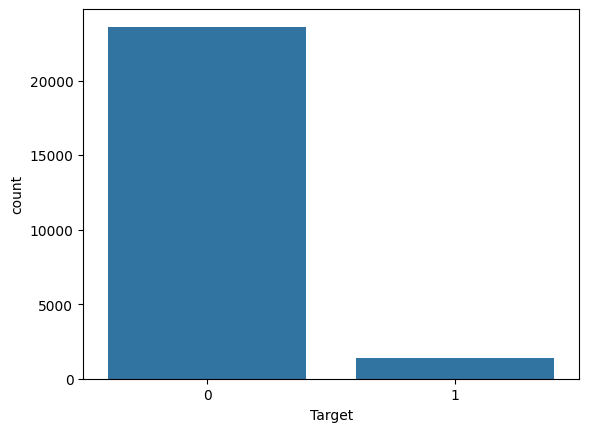

In [28]:
#visual representation of instances per class
sns.countplot(data=fullset, x='Target');

In [29]:
#pulling in our function to make histplots/boxplots together

def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

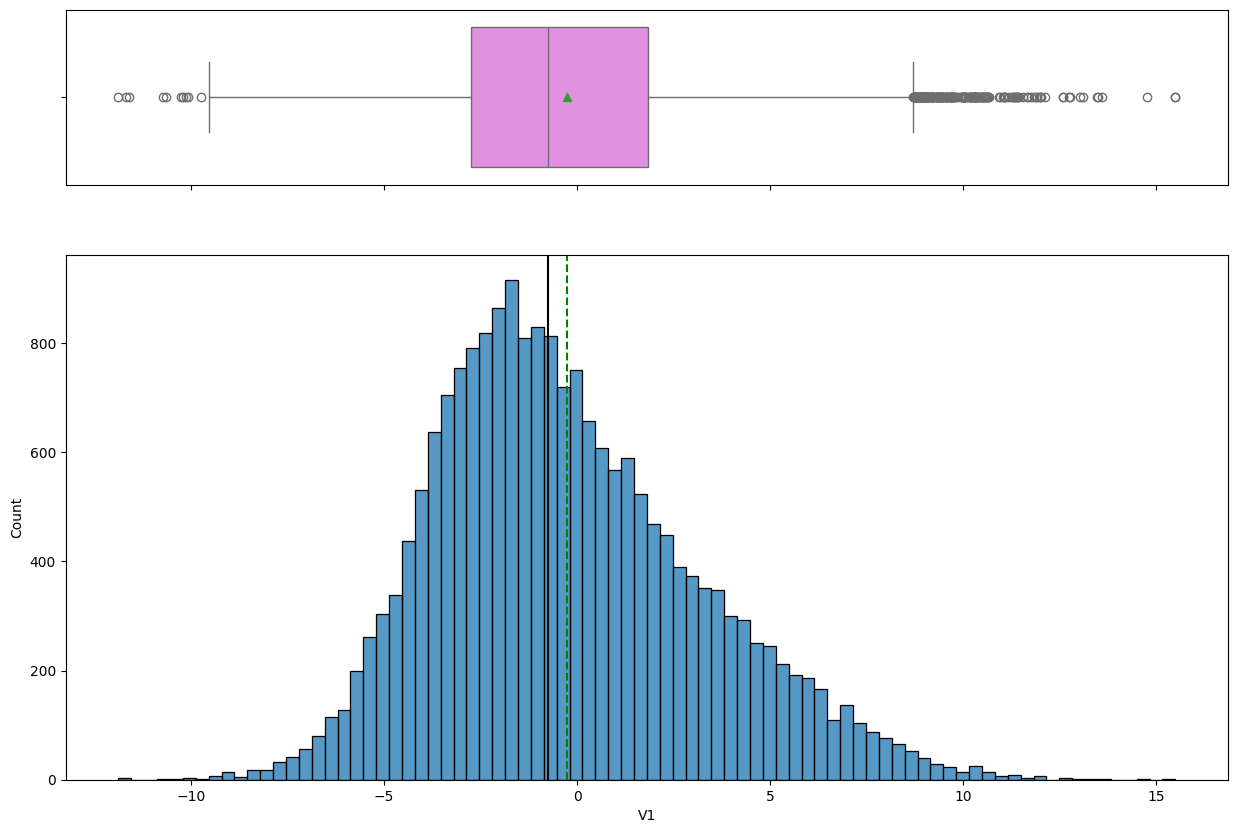

In [30]:
#taking a closer look at the variables that have missing values -- v1 and v2 --
#so we have a better idea of what we should impute
histogram_boxplot(df, 'V1')

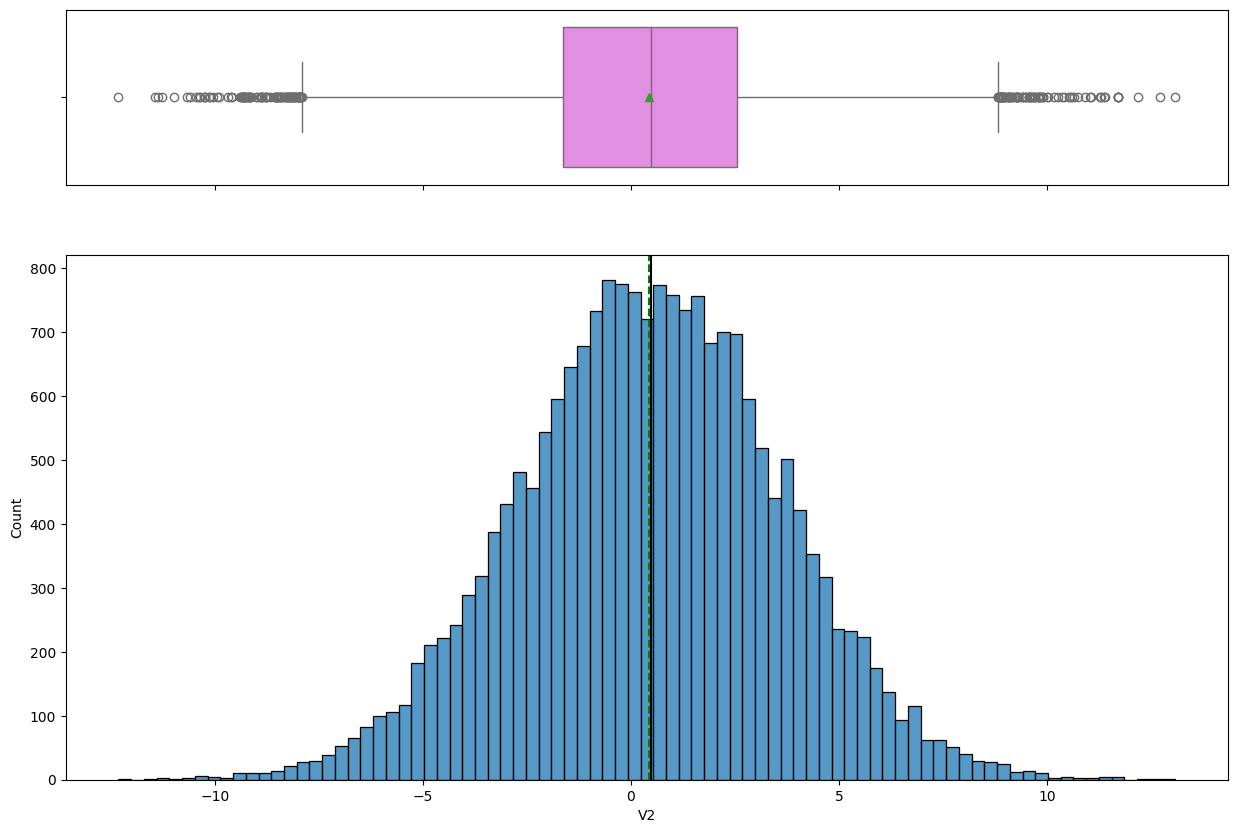

In [31]:
histogram_boxplot(df, 'V2')

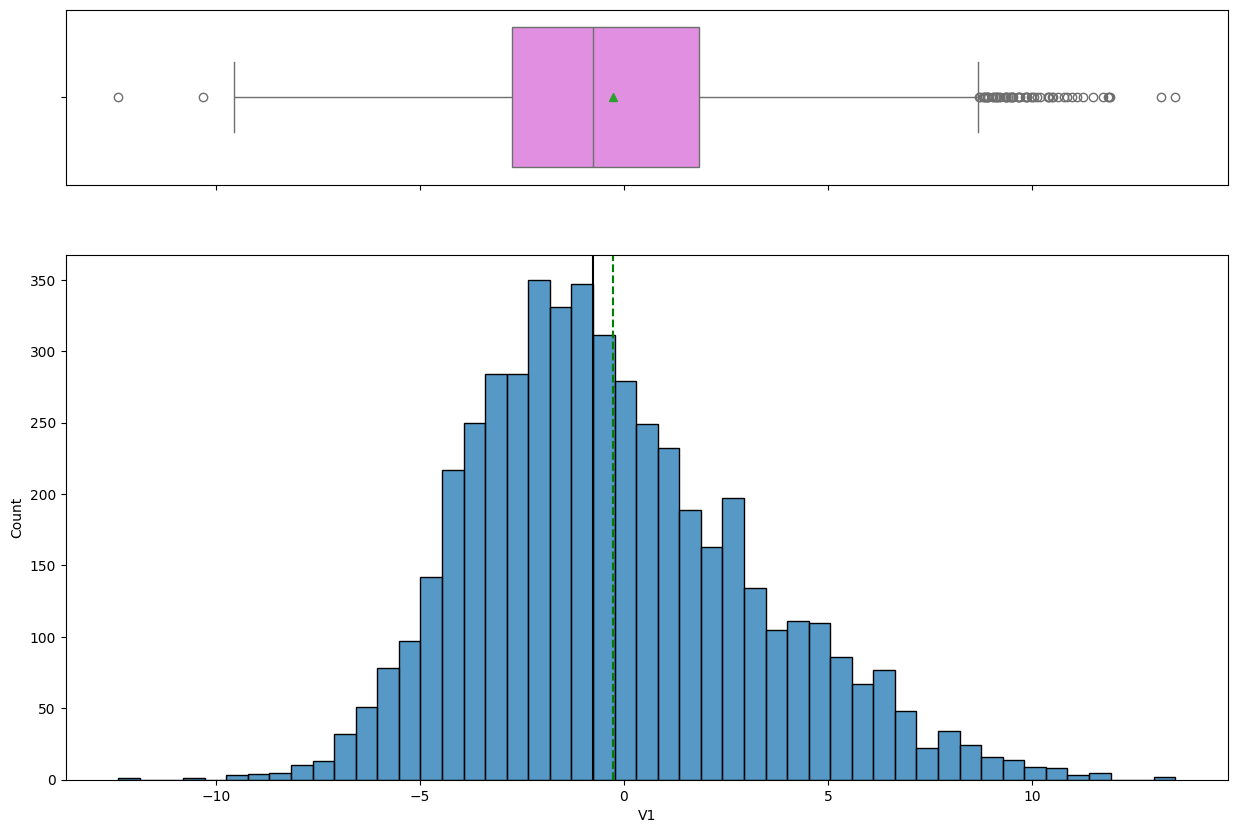

In [32]:
histogram_boxplot(testset, 'V1')

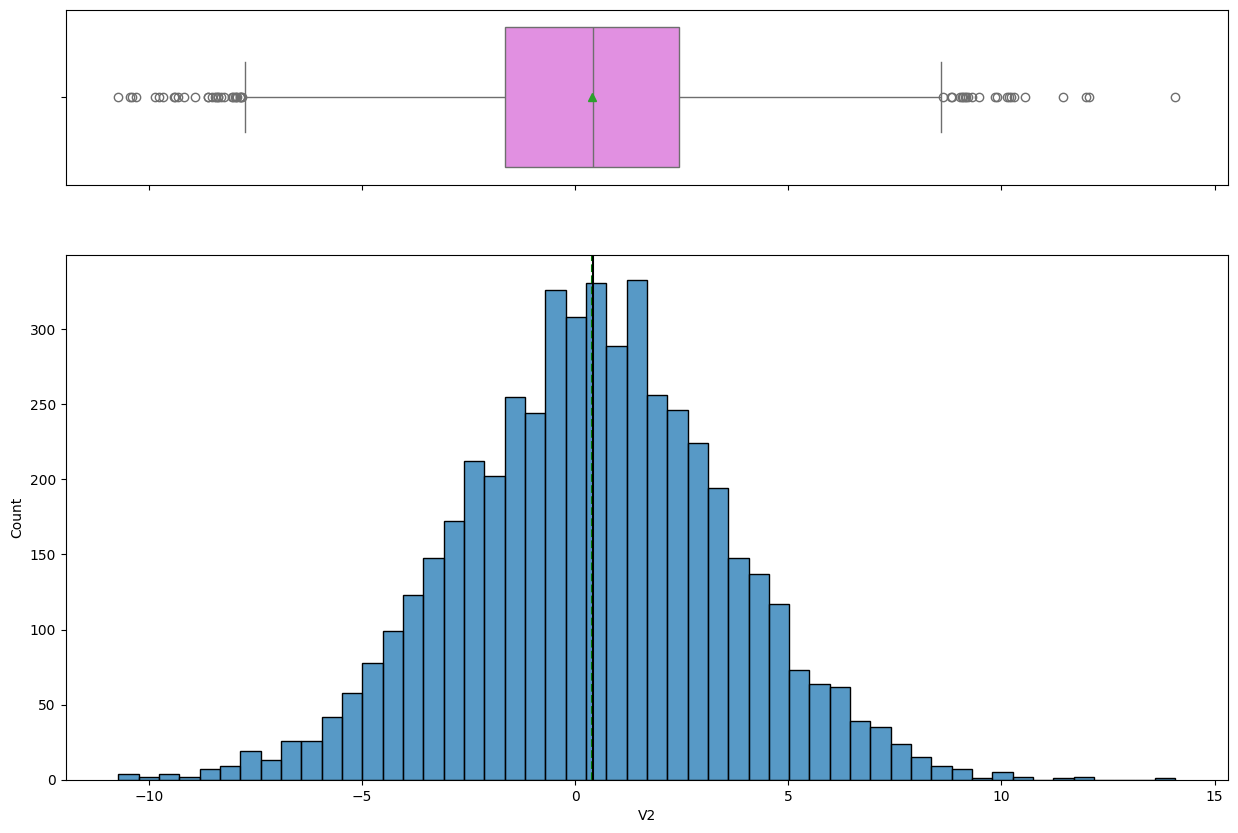

In [33]:
histogram_boxplot(testset, 'V2')

* Both V1 and V2 have some outliers, and for V1, the outliers on the high end appear to be influencing the mean. It's less of a problem for V2, because there are outlieres on both ends
* That said, median feels like the better choice for imputing -- which we'll do later

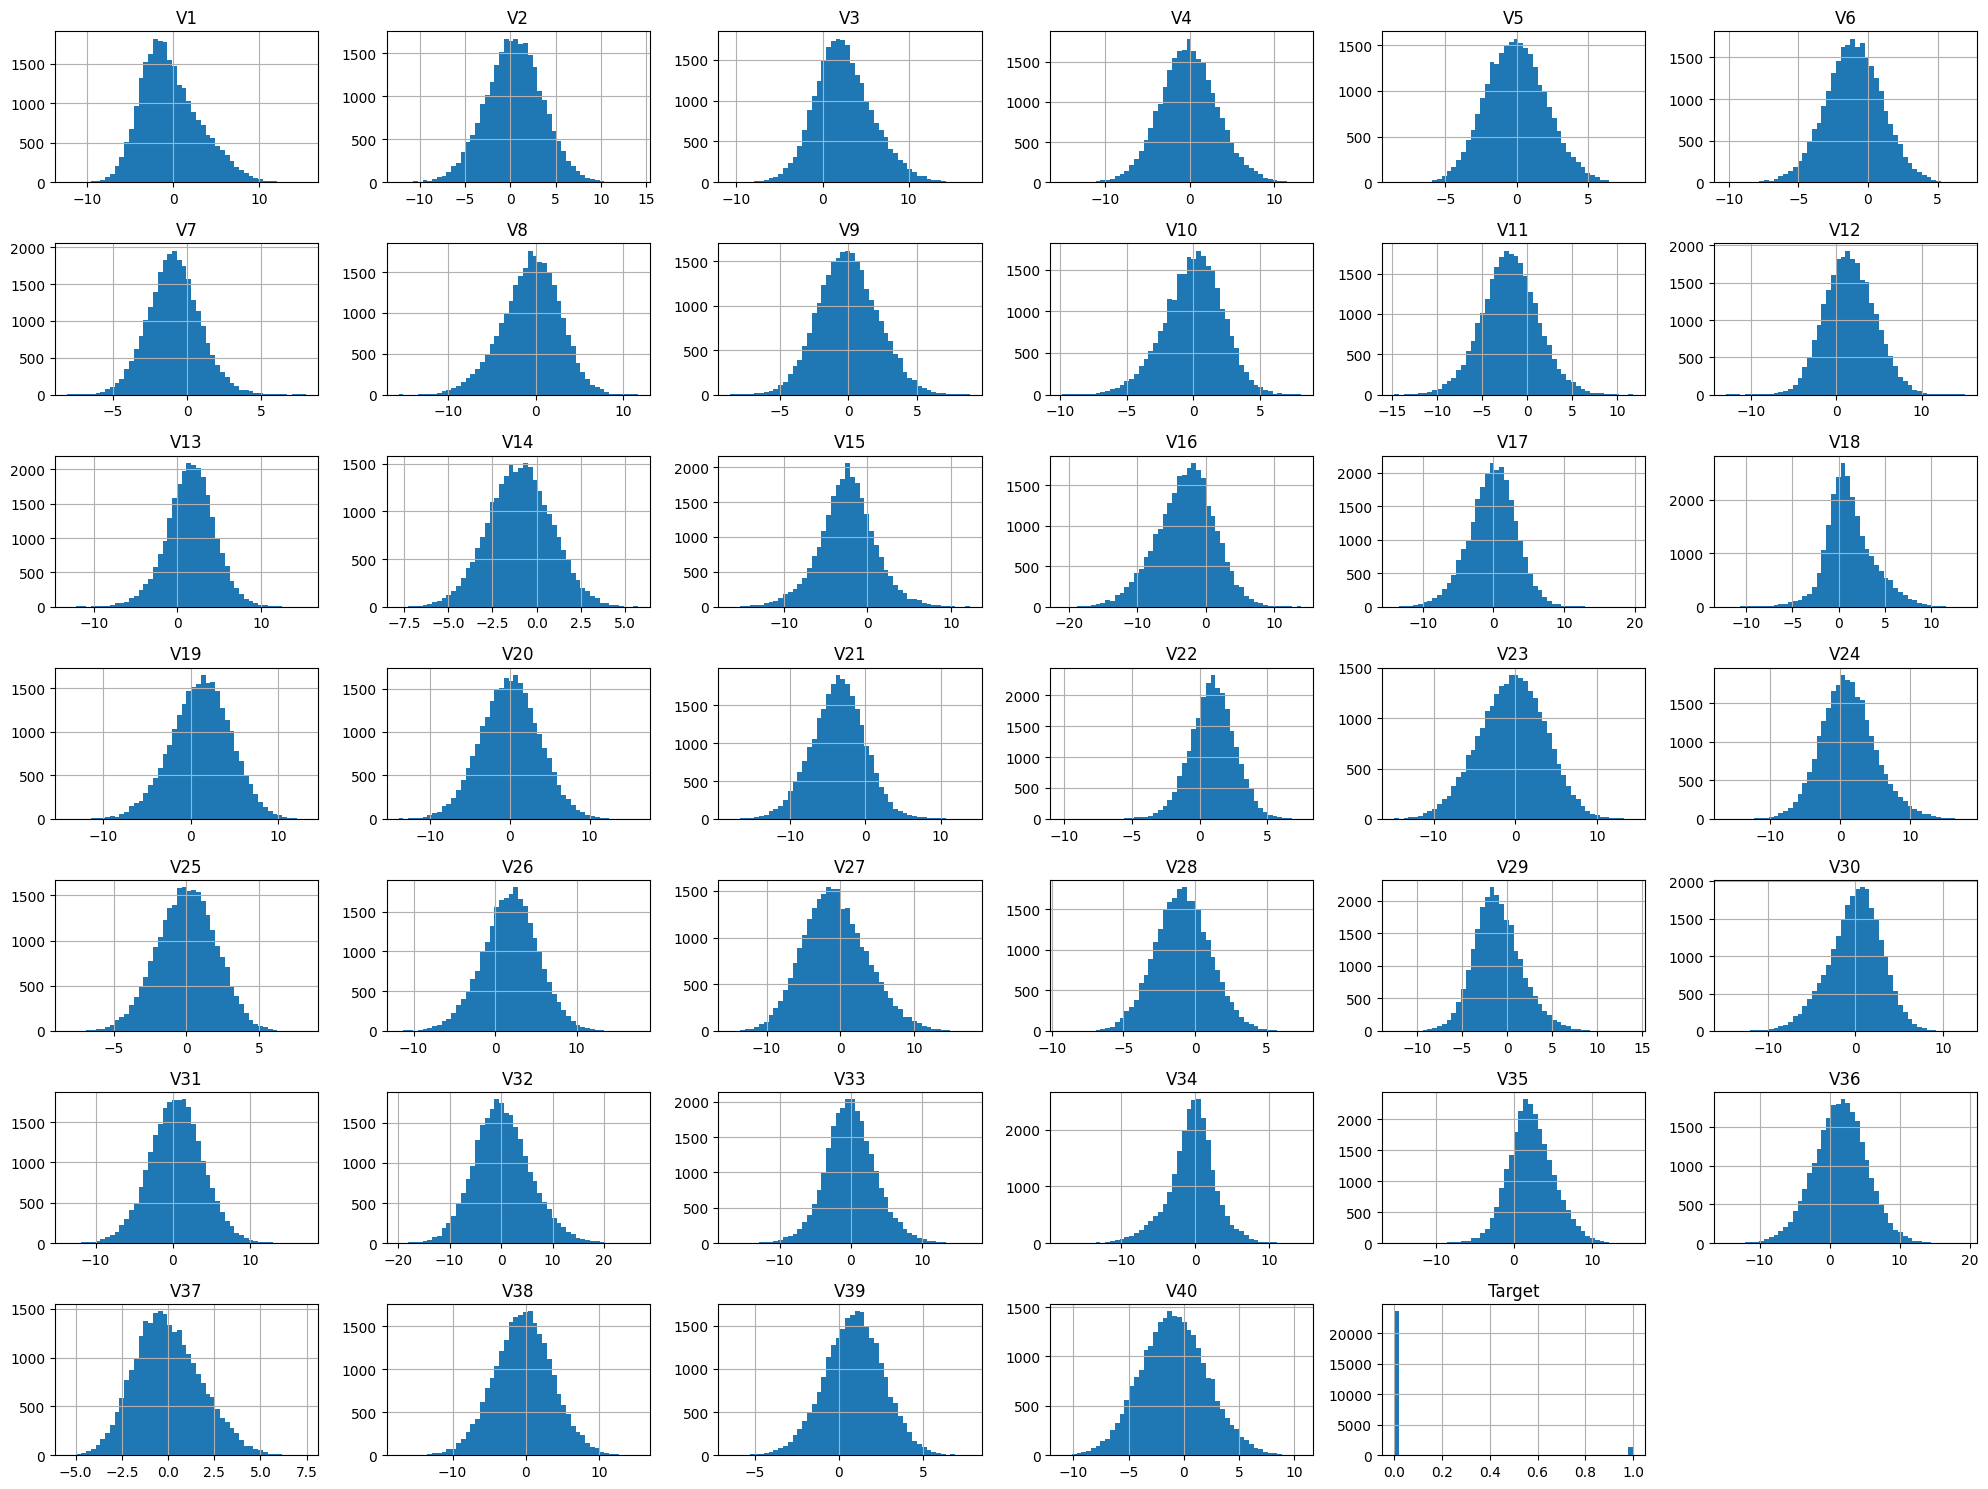

In [34]:
#make histplots for each variable
fullset.hist(bins = 50, figsize = (20, 15));
plt.tight_layout()

* All the variables appear to have mostly-normal distributions

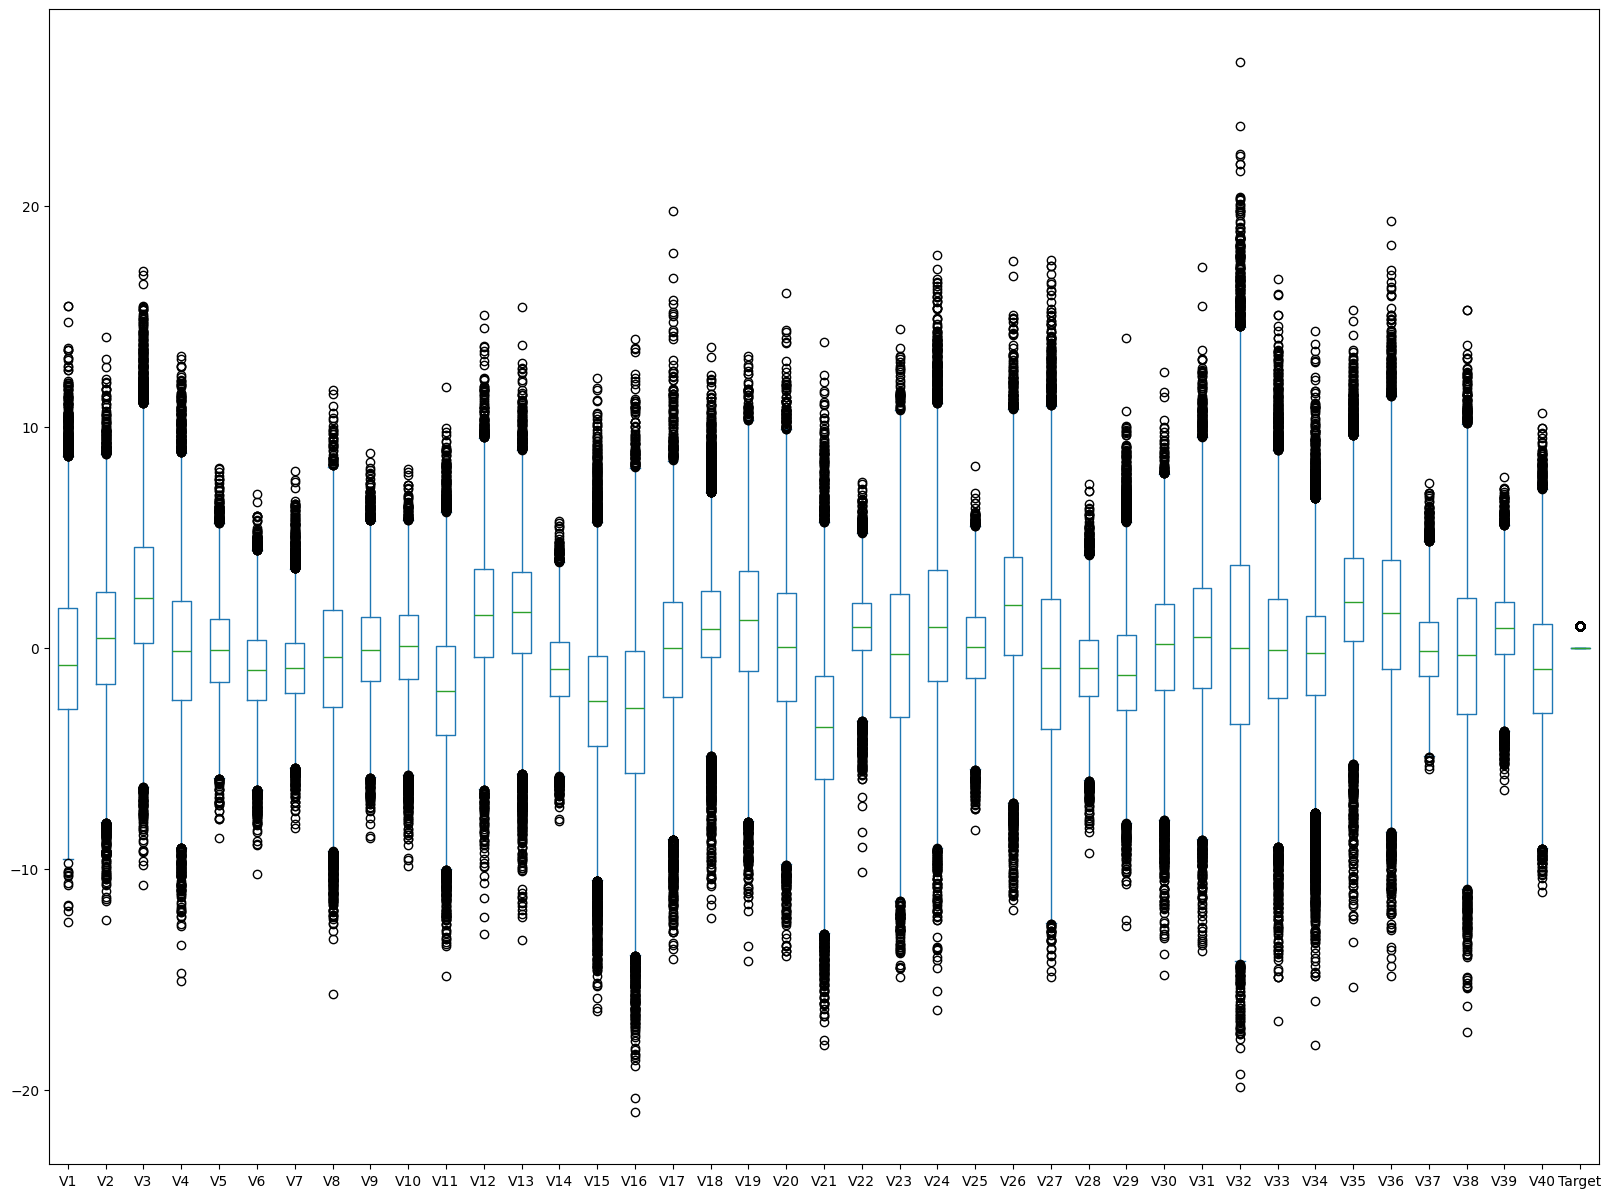

In [35]:
#make boxplots for all the variables
fullset.plot.box(figsize = (20, 15));

* All the variables look mostly the same -- with mostly-normal distribution and outliers on both ends
* In the target variable, 1s (generator failures) appear to be outliers

## Bivariate Analysis

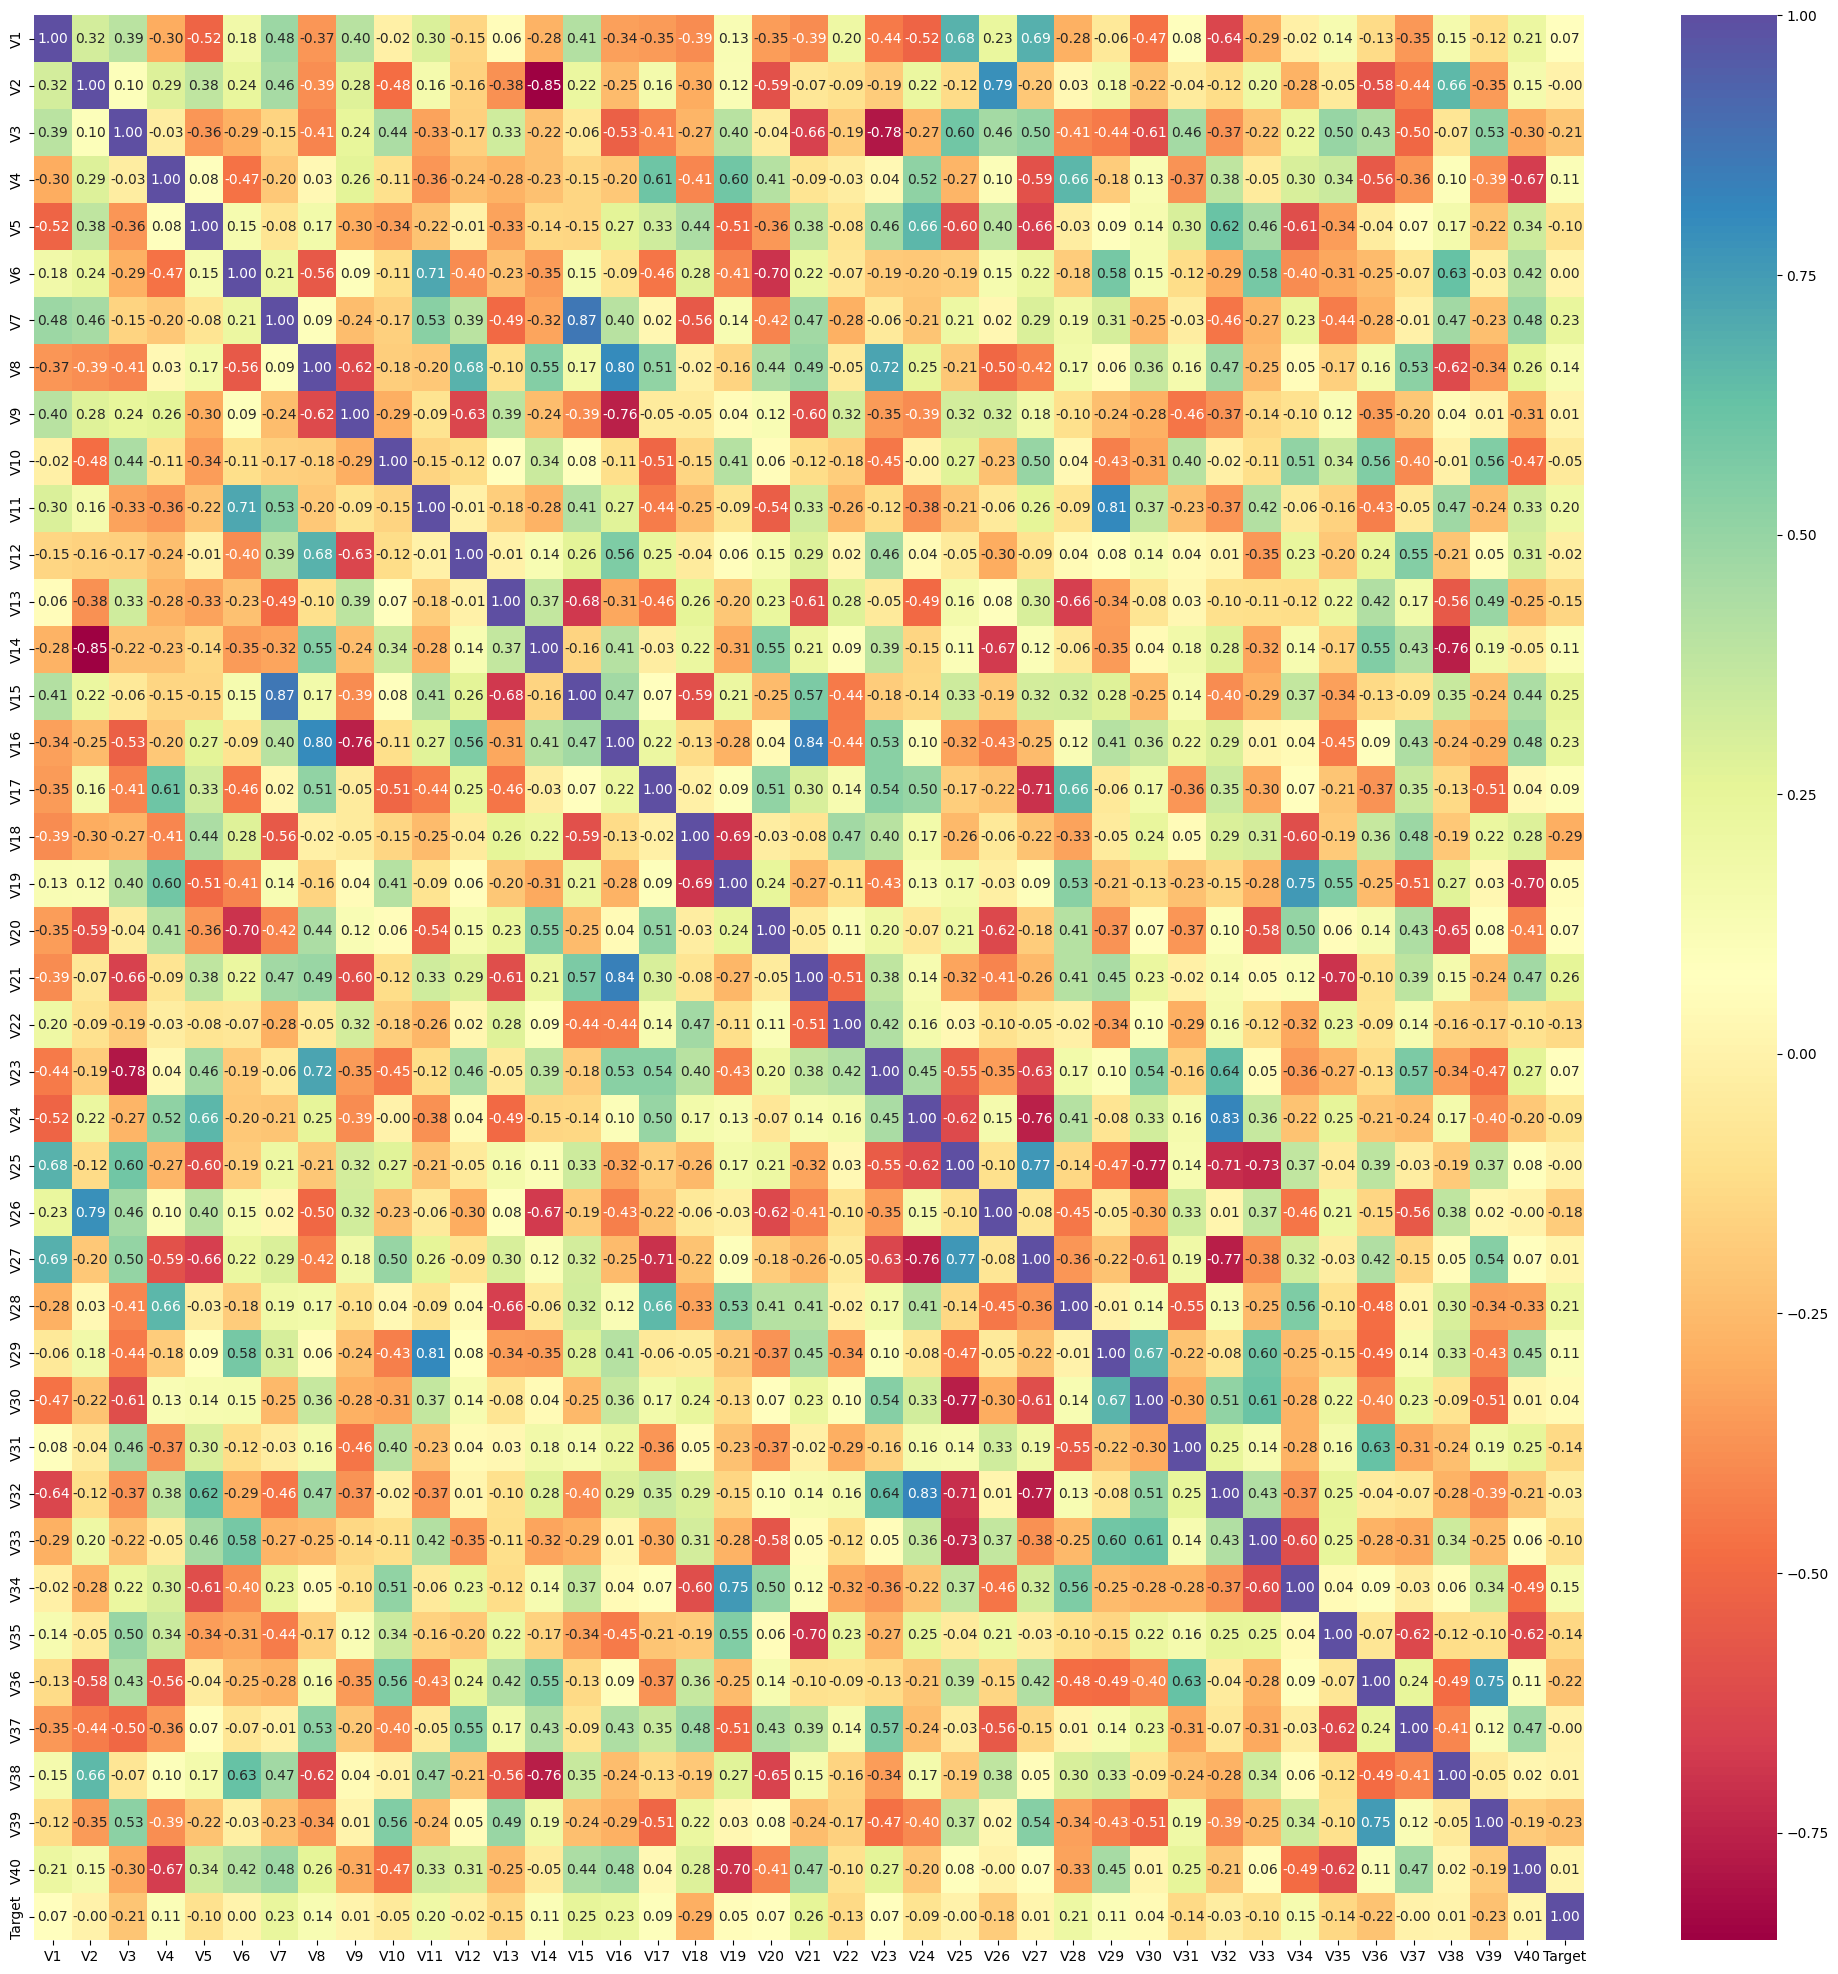

In [36]:
#heatmap
plt.figure(figsize=(25, 25))
sns.heatmap(data=fullset.corr(), annot=True, cmap='Spectral', fmt = ".2f");

* The Target variable isn't really correlated or negatively correlated with any other variables*
* Some variables appear to be correlated with others -- V15/V7 (0.87), V16/V8 (0.80), V29/V11 (0.81), V21/V16 (0.84), and V32/V24 (0.83) stand out
* On the negative side, V14/V2 (0.85) stands out

# **Data Preprocessing**

We'll split the training set into training and validation first, then impute missing values in both as well as testing set. Split first, then impute to avoid data leakage

In [37]:
#set up X and y
X = df.drop(['Target'], axis=1)
y = df['Target']

In [38]:
#drop the target variable from the test set for later
X_test = testset.drop(['Target'], axis=1)
y_test = testset[('Target')]

In [39]:
#split training set into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.30, random_state = 1, stratify = y)

In [40]:
#see how it looks
print(X_train.shape, X_val.shape, X_test.shape)

(14000, 40) (6000, 40) (5000, 40)


In [41]:
#impute values into the three data sets

imputer_mode = SimpleImputer(strategy="median")
X_train[['V1', 'V2']] = imputer_mode.fit_transform(X_train[['V1', 'V2']])
X_val[['V1', 'V2']] = imputer_mode.fit_transform(X_val[['V1', 'V2']])
X_test[['V1', 'V2']] = imputer_mode.fit_transform(testset[['V1', 'V2']])

In [42]:
#checking the three data sets for missing values again
X_train.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [43]:
X_val.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [44]:
X_test.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [45]:
print(y_train.shape, y_val.shape, y_test.shape)

(14000,) (6000,) (5000,)


# **Model Building**

## Model Evaluation Criterion

Write down the model evaluation criterion with rationale

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

The model can make wrong predictions by:
* Predicting a generator will fail, when it won't (false positive) -- results in inspection cost
* Predicting a generator will not fail, when it will (false negative) -- results in replacement cost

Which is most important?
* The cost of predicting a generator will not fail, when it will, is the highest since it results in replacement costs
* The cost of predicting a generator will fail, when it won't , merely results in inspection costs -- which are lower than either replacement or repair costs
* This means the cost of a false negative is highest

How do we reduce the loss?
* We want to minimize false negatives since they're costliest -- thus, we want to use recall as our metric

In [46]:
#pulling in function to plot the loss/recall
def plot(history, name):
    """
    Function to plot loss/recall

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Recall
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train recall or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation recall or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

In [47]:
#Defining dataframe columns
columns = ["# hidden layers","# neurons - hidden layer","activation function - hidden layer ","# epochs","batch size","optimizer","learning rate, momentum","weight initializer","regularization","train loss","validation loss","train recall","validation recall","time (secs)"]


#Creating a pandas dataframe.
results = pd.DataFrame(columns=columns)

In [48]:
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)


## Initial Model Building (Model 0)

- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer

In [49]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model0 = Sequential()

#hidden layer
model0.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model0.add(Dense(1, activation = 'sigmoid'))

In [50]:
#looking at model details
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
#defining optimizer
optimizer = keras.optimizers.SGD()

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model0.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [52]:
#defining batch size and epochs
batch_size = 100
epochs = 50

#fitting model
start = time.time()
history = model0.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end = time.time()

Epoch 1/50
140/140 - 1s - 9ms/step - loss: 0.2003 - recall: 0.3745 - val_loss: 0.1311 - val_recall: 0.4685
Epoch 2/50
140/140 - 1s - 7ms/step - loss: 0.1165 - recall: 0.4891 - val_loss: 0.1126 - val_recall: 0.5556
Epoch 3/50
140/140 - 0s - 3ms/step - loss: 0.1019 - recall: 0.5521 - val_loss: 0.1040 - val_recall: 0.6186
Epoch 4/50
140/140 - 1s - 5ms/step - loss: 0.0939 - recall: 0.6075 - val_loss: 0.0988 - val_recall: 0.6547
Epoch 5/50
140/140 - 1s - 5ms/step - loss: 0.0885 - recall: 0.6474 - val_loss: 0.0950 - val_recall: 0.6817
Epoch 6/50
140/140 - 1s - 9ms/step - loss: 0.0844 - recall: 0.6782 - val_loss: 0.0920 - val_recall: 0.6937
Epoch 7/50
140/140 - 1s - 10ms/step - loss: 0.0811 - recall: 0.6898 - val_loss: 0.0896 - val_recall: 0.7027
Epoch 8/50
140/140 - 1s - 6ms/step - loss: 0.0784 - recall: 0.7053 - val_loss: 0.0875 - val_recall: 0.7117
Epoch 9/50
140/140 - 0s - 3ms/step - loss: 0.0761 - recall: 0.7233 - val_loss: 0.0857 - val_recall: 0.7237
Epoch 10/50
140/140 - 1s - 5ms/step 

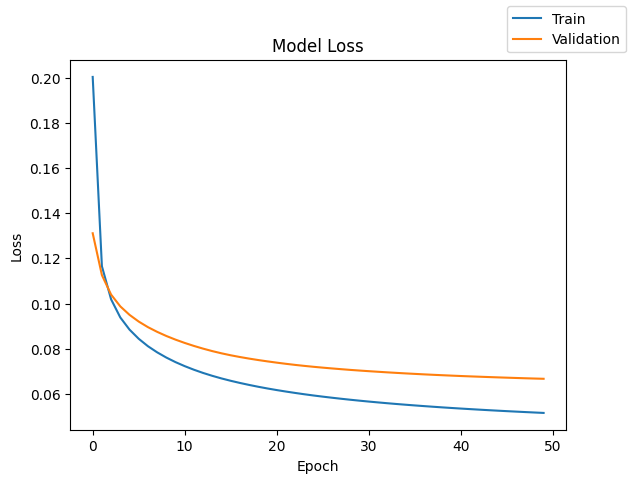

In [53]:
#plot model's loss
plot(history, 'loss')

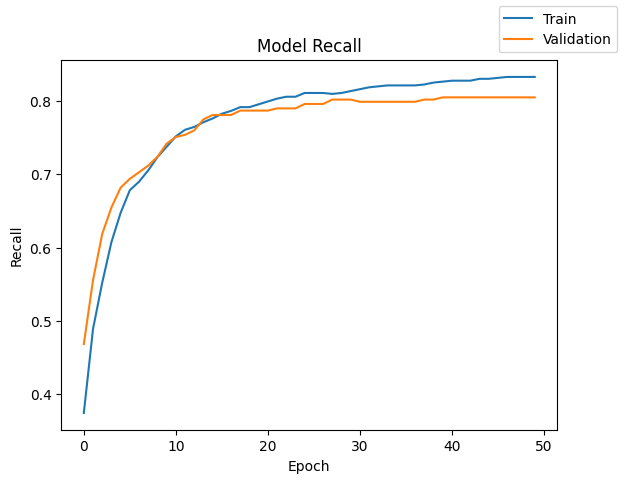

In [54]:
#plot model's recall
plot(history,'recall')

* We have steep drops in loss up until around the 3rd epoch
* Our loss starts to flatten out around 3 epochs, and the validation loss is higher than the training loss after about 2 epochs
* When it comes to recall, both show steep improvement until around 10 epochs, when it starts to flatten out
* Validation performance is overall better than training performance until around 14 epochs, which could mean this is where the model starts to overfit

In [55]:
#add model to our results df
results.loc[0] = [
  1, #hidden layers
  64, #neurons/layer
  "relu", #activation function
  epochs, #epochs
  batch_size, #batch size
  "SGD", #optimizer
  [0.001,"-"], # learning rate, momentum
  "-", #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.83269,0.804805,34.11


# **Model Performance Improvement**

## Model 1

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* SGD optimizer

In [56]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model1 = Sequential()

#hidden layer
model1.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model1.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model1.add(Dense(1, activation = 'sigmoid'))

In [57]:
#looking at model details
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
#defining optimizer
optimizer = keras.optimizers.SGD()

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model1.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [59]:
#defining batch size and epochs
batch_size = 100
epochs = 50

#fitting model
start = time.time()
history = model1.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end = time.time()

Epoch 1/50
140/140 - 1s - 9ms/step - loss: 0.1678 - recall: 0.2046 - val_loss: 0.1341 - val_recall: 0.3423
Epoch 2/50
140/140 - 1s - 7ms/step - loss: 0.1210 - recall: 0.4118 - val_loss: 0.1147 - val_recall: 0.5105
Epoch 3/50
140/140 - 0s - 3ms/step - loss: 0.1060 - recall: 0.5135 - val_loss: 0.1046 - val_recall: 0.6096
Epoch 4/50
140/140 - 0s - 3ms/step - loss: 0.0969 - recall: 0.5753 - val_loss: 0.0980 - val_recall: 0.6486
Epoch 5/50
140/140 - 1s - 5ms/step - loss: 0.0904 - recall: 0.6100 - val_loss: 0.0930 - val_recall: 0.6847
Epoch 6/50
140/140 - 1s - 4ms/step - loss: 0.0854 - recall: 0.6345 - val_loss: 0.0892 - val_recall: 0.7207
Epoch 7/50
140/140 - 0s - 3ms/step - loss: 0.0814 - recall: 0.6615 - val_loss: 0.0861 - val_recall: 0.7267
Epoch 8/50
140/140 - 0s - 3ms/step - loss: 0.0780 - recall: 0.6808 - val_loss: 0.0835 - val_recall: 0.7447
Epoch 9/50
140/140 - 0s - 3ms/step - loss: 0.0751 - recall: 0.7104 - val_loss: 0.0813 - val_recall: 0.7568
Epoch 10/50
140/140 - 1s - 4ms/step -

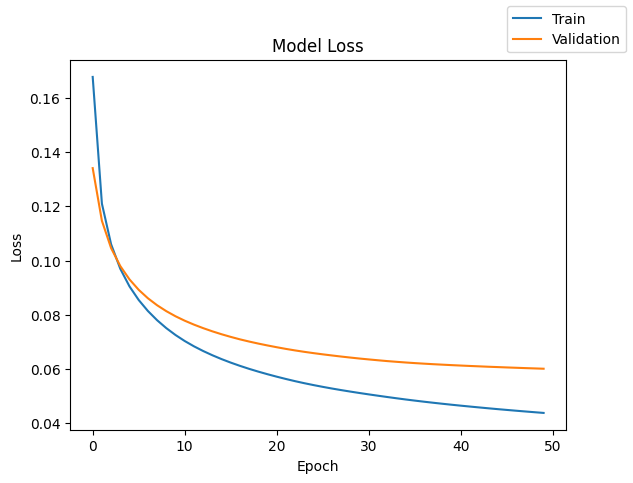

In [60]:
#plot model's loss
plot(history, 'loss')

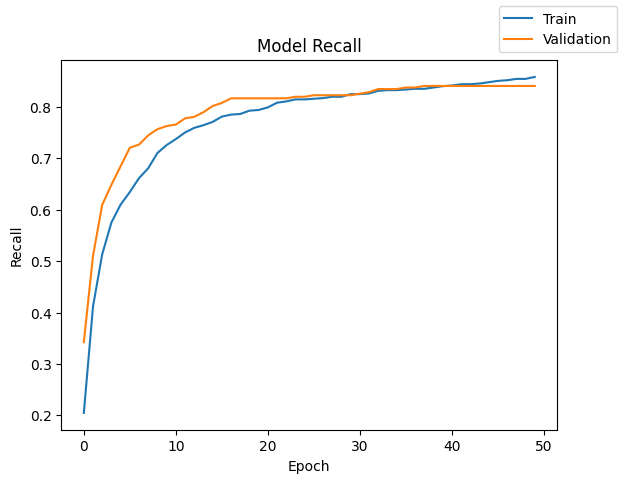

In [61]:
#plot model's recall
plot(history,'recall')

* We have steep drops in loss until about the 5th epoch before it begins slowing down and plateauing
* Validation loss is higher than training loss after about the 4th epoch
* For recall, both show steep improvement until about the 8th epoch, before it starts to slow down and plateau
* Validation performance is overall better than training performance until about the 21st epoch, when both are very similar
* Training performance is better after the 40th epoch

In [62]:
#add model to our results df
results.loc[1] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "SGD", #optimizer
  [0.001,"-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.83269,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.85843,0.840841,32.27


## Model 2

Plan:
* Two hidden layers -- 64, 64
* activation function -- relu, tanh
* SGD optimizer

In [63]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model2 = Sequential()

#hidden layer
model2.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model2.add(Dense(64, activation = 'tanh'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model2.add(Dense(1, activation = 'sigmoid'))

In [64]:
#looking at model details
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
#defining optimizer
optimizer = keras.optimizers.SGD()

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model2.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [66]:
#defining batch size and epochs
batch_size = 100
epochs = 50

#fitting model
start = time.time()
history = model2.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/50
140/140 - 2s - 11ms/step - loss: 0.1799 - recall: 0.1802 - val_loss: 0.1355 - val_recall: 0.2252
Epoch 2/50
140/140 - 1s - 8ms/step - loss: 0.1246 - recall: 0.2896 - val_loss: 0.1182 - val_recall: 0.3694
Epoch 3/50
140/140 - 1s - 9ms/step - loss: 0.1097 - recall: 0.4003 - val_loss: 0.1080 - val_recall: 0.4505
Epoch 4/50
140/140 - 1s - 4ms/step - loss: 0.0999 - recall: 0.4762 - val_loss: 0.1009 - val_recall: 0.5045
Epoch 5/50
140/140 - 1s - 4ms/step - loss: 0.0928 - recall: 0.5251 - val_loss: 0.0956 - val_recall: 0.5465
Epoch 6/50
140/140 - 0s - 3ms/step - loss: 0.0873 - recall: 0.5663 - val_loss: 0.0914 - val_recall: 0.5796
Epoch 7/50
140/140 - 0s - 3ms/step - loss: 0.0828 - recall: 0.6010 - val_loss: 0.0879 - val_recall: 0.6126
Epoch 8/50
140/140 - 1s - 4ms/step - loss: 0.0790 - recall: 0.6281 - val_loss: 0.0850 - val_recall: 0.6396
Epoch 9/50
140/140 - 1s - 5ms/step - loss: 0.0758 - recall: 0.6499 - val_loss: 0.0825 - val_recall: 0.6607
Epoch 10/50
140/140 - 1s - 4ms/step 

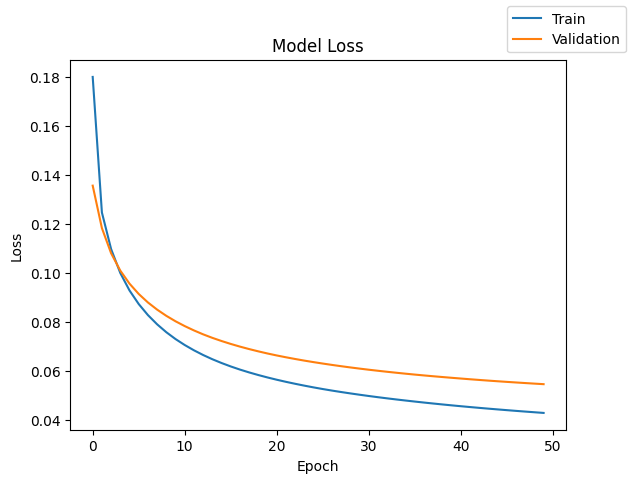

In [67]:
#plot model's loss
plot(history, 'loss')

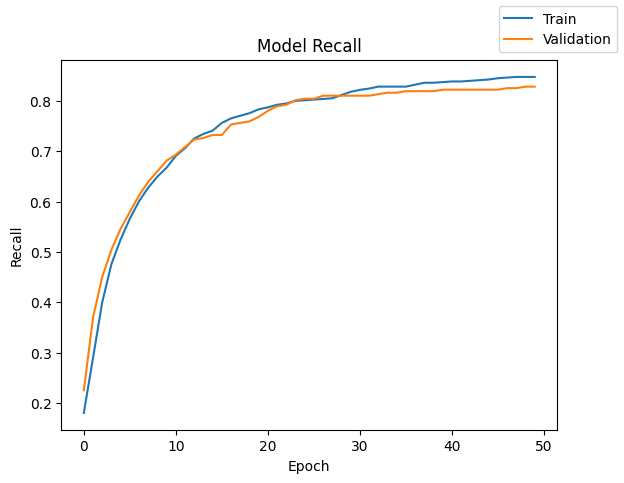

In [68]:
#plot model's recall
plot(history,'recall')

* We have steep drops in loss until around the 5th epoch, then the decreases are less steep
* Validation loss is higher than training loss after around 5 epochs
* For recall, we have steep increases until around 10 epochs, when it starts slowing and plateauing
* Validation performance is similar to the training performanceuntil around 30 epochs, when training recall becomes higher
* That said, there is a slim gap

In [69]:
#add model to our results df
results.loc[2] = [
  2, #hidden layers
  [64, 64], #neurons/layer
  ["relu", "tanh"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "SGD", #optimizer
  [0.001,"-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36


## Model 3

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* SGD with momentum

In [70]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model3 = Sequential()

#hidden layer
model3.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model3.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model3.add(Dense(1, activation = 'sigmoid'))

In [71]:
#looking at model details
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
#defining optimizer
mom = 0.9
optimizer = keras.optimizers.SGD(momentum = mom)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model3.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [73]:
#defining batch size and epochs
batch_size = 100
epochs = 50

#fitting model
start = time.time()
history = model3.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/50
140/140 - 2s - 11ms/step - loss: 0.1490 - recall: 0.5290 - val_loss: 0.0856 - val_recall: 0.7267
Epoch 2/50
140/140 - 0s - 3ms/step - loss: 0.0703 - recall: 0.7683 - val_loss: 0.0718 - val_recall: 0.7928
Epoch 3/50
140/140 - 0s - 3ms/step - loss: 0.0592 - recall: 0.8069 - val_loss: 0.0656 - val_recall: 0.8078
Epoch 4/50
140/140 - 0s - 3ms/step - loss: 0.0533 - recall: 0.8301 - val_loss: 0.0623 - val_recall: 0.8258
Epoch 5/50
140/140 - 1s - 4ms/step - loss: 0.0494 - recall: 0.8456 - val_loss: 0.0601 - val_recall: 0.8348
Epoch 6/50
140/140 - 0s - 3ms/step - loss: 0.0466 - recall: 0.8559 - val_loss: 0.0585 - val_recall: 0.8378
Epoch 7/50
140/140 - 0s - 3ms/step - loss: 0.0444 - recall: 0.8649 - val_loss: 0.0573 - val_recall: 0.8378
Epoch 8/50
140/140 - 1s - 4ms/step - loss: 0.0425 - recall: 0.8687 - val_loss: 0.0564 - val_recall: 0.8378
Epoch 9/50
140/140 - 1s - 6ms/step - loss: 0.0409 - recall: 0.8777 - val_loss: 0.0556 - val_recall: 0.8438
Epoch 10/50
140/140 - 1s - 6ms/step 

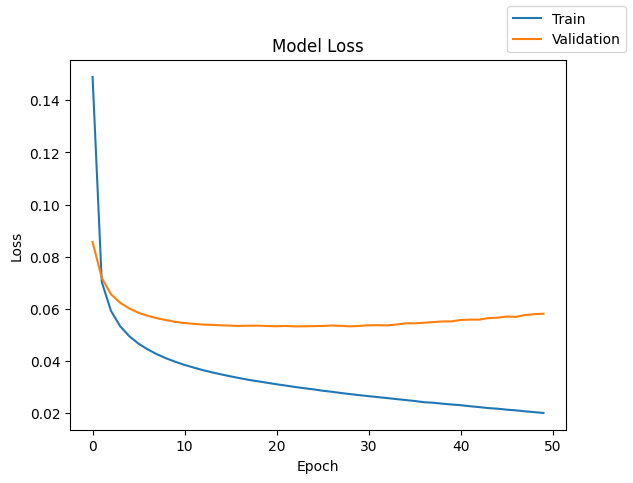

In [74]:
#plot model's loss
plot(history, 'loss')

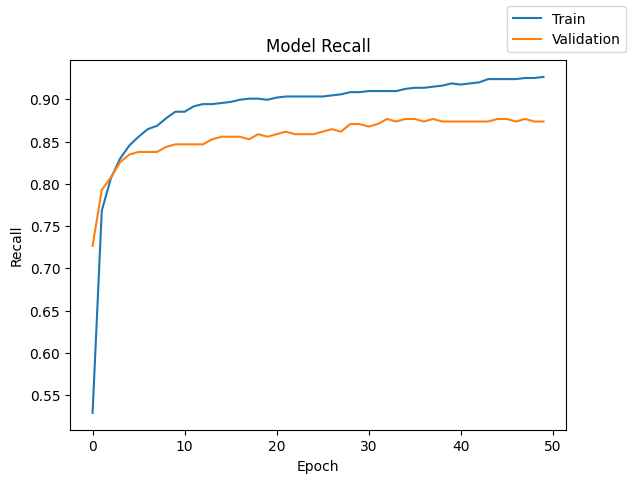

In [75]:
#plot model's recall
plot(history,'recall')

* We see steep drops in loss until about the 5th or 6th epoch -- then, validation losses generally level off before generally increasing
* Meantime, training loss continues to drop, though less quickly -- meaning we could be overfitting after this point
* Regarding recall, both training and validation show dramatic increases until about the 4th epoch
* After that, validation starts to plateau and oscillate, though it generally increases until about the 30th epoch, before generally levelling off
* Training continues to improve, though at a slower rate

In [76]:
#add model to our results df
results.loc[3] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "SGD with mom", #optimizer
  [0.001,0.9], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45


## Model 4

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* SGD optimizer with momentum
* Reduced learning rate of 1e-4, and increase epochs to 100

In [77]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model4 = Sequential()

#hidden layer
model4.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model4.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model4.add(Dense(1, activation = 'sigmoid'))

In [78]:
#looking at model details
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
#defining optimizer
lr = 1e-4
mom = 0.9
optimizer = keras.optimizers.SGD(momentum = mom, learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model4.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [80]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model4.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 2s - 17ms/step - loss: 0.3403 - recall: 0.1879 - val_loss: 0.1945 - val_recall: 0.0270
Epoch 2/100
140/140 - 0s - 3ms/step - loss: 0.1839 - recall: 0.0322 - val_loss: 0.1769 - val_recall: 0.0330
Epoch 3/100
140/140 - 1s - 5ms/step - loss: 0.1713 - recall: 0.0528 - val_loss: 0.1674 - val_recall: 0.0631
Epoch 4/100
140/140 - 0s - 3ms/step - loss: 0.1627 - recall: 0.0798 - val_loss: 0.1601 - val_recall: 0.1141
Epoch 5/100
140/140 - 0s - 3ms/step - loss: 0.1559 - recall: 0.1171 - val_loss: 0.1542 - val_recall: 0.1441
Epoch 6/100
140/140 - 1s - 4ms/step - loss: 0.1502 - recall: 0.1660 - val_loss: 0.1493 - val_recall: 0.1712
Epoch 7/100
140/140 - 1s - 5ms/step - loss: 0.1453 - recall: 0.1995 - val_loss: 0.1450 - val_recall: 0.2012
Epoch 8/100
140/140 - 1s - 4ms/step - loss: 0.1411 - recall: 0.2317 - val_loss: 0.1413 - val_recall: 0.2312
Epoch 9/100
140/140 - 1s - 4ms/step - loss: 0.1374 - recall: 0.2728 - val_loss: 0.1379 - val_recall: 0.2583
Epoch 10/100
140/140 - 0s -

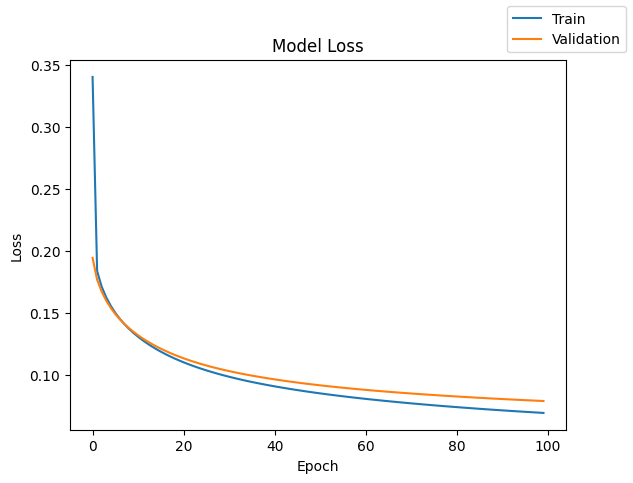

In [81]:
#plot model's loss
plot(history, 'loss')

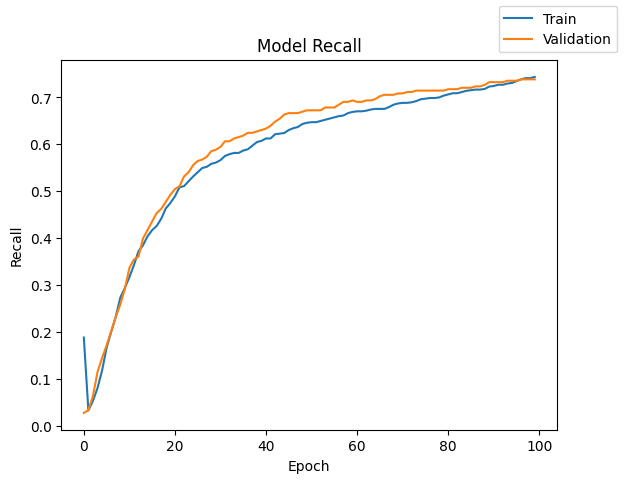

In [82]:
#plot model's recall
plot(history,'recall')

* We see steep drops in loss until about the 10th epoch, then the decreases are less steep
* Validation losses are higher after about 15 epochs, but not by much -- though the gap starts to get wider after 40 epochs
* When it comes to recall, training and validation see steep increases until about 30 epochs, then the increases are less steep
* Validation recall becomes consistently higher after about 22 epochs, until about 90 epochs when training recall becomes higher -- this may be where we start overfitting a bit more

In [83]:
#add model to our results df
results.loc[4] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "SGD with mom", #optimizer
  [0.0001, 0.9], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58


## Model 5

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer

In [84]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model5 = Sequential()

#hidden layer
model5.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model5.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model5.add(Dense(1, activation = 'sigmoid'))

In [85]:
#looking at model details
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
#defining optimizer
optimizer = keras.optimizers.Adam()

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model5.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [87]:
#defining batch size and epochs
batch_size = 100
epochs = 50

#fitting model
start = time.time()
history = model5.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/50
140/140 - 2s - 14ms/step - loss: 0.1239 - recall: 0.5071 - val_loss: 0.0786 - val_recall: 0.7658
Epoch 2/50
140/140 - 1s - 7ms/step - loss: 0.0620 - recall: 0.8005 - val_loss: 0.0637 - val_recall: 0.8138
Epoch 3/50
140/140 - 0s - 3ms/step - loss: 0.0508 - recall: 0.8520 - val_loss: 0.0600 - val_recall: 0.8318
Epoch 4/50
140/140 - 1s - 5ms/step - loss: 0.0456 - recall: 0.8700 - val_loss: 0.0585 - val_recall: 0.8318
Epoch 5/50
140/140 - 0s - 3ms/step - loss: 0.0421 - recall: 0.8739 - val_loss: 0.0579 - val_recall: 0.8348
Epoch 6/50
140/140 - 1s - 4ms/step - loss: 0.0396 - recall: 0.8829 - val_loss: 0.0577 - val_recall: 0.8408
Epoch 7/50
140/140 - 1s - 5ms/step - loss: 0.0376 - recall: 0.8893 - val_loss: 0.0580 - val_recall: 0.8438
Epoch 8/50
140/140 - 1s - 4ms/step - loss: 0.0360 - recall: 0.8932 - val_loss: 0.0579 - val_recall: 0.8468
Epoch 9/50
140/140 - 1s - 4ms/step - loss: 0.0347 - recall: 0.8945 - val_loss: 0.0582 - val_recall: 0.8498
Epoch 10/50
140/140 - 1s - 4ms/step 

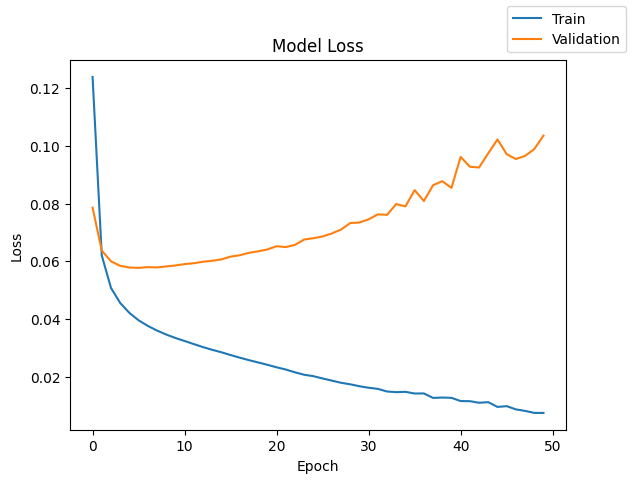

In [88]:
#plot model's loss
plot(history, 'loss')

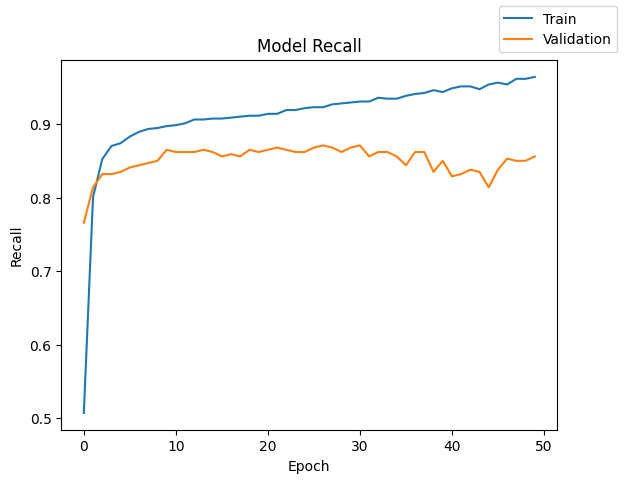

In [89]:
#plot model's recall
plot(history,'recall')

* There is a big gap between training and validation loss-- validation drops until about the 4th epoch, then increases gradually before oscillating and increasing even more at 35 epochs
* Meantime, training loss keeps falling all the way to 50 epochs
* For recall, training increases gradually until about 4 epochs, then continues increasing gradually
* Validation recall increases greatly until about 4 epochs, then has slowing increases before oscillating after 10 epochs, then dropping a bit until 42 epochs and increasing again
* The large gaps and zig-zagging may be signs of overfitting

In [90]:
#add model to our results df
results.loc[5] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.001,"-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18


## Model 6

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100

In [91]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model6 = Sequential()

#hidden layer
model6.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#hidden layer
model6.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model6.add(Dense(1, activation = 'sigmoid'))

In [92]:
#looking at model details
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [93]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model6.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [94]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model6.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 3s - 22ms/step - loss: 0.4065 - recall: 0.1596 - val_loss: 0.1999 - val_recall: 0.0390
Epoch 2/100
140/140 - 0s - 4ms/step - loss: 0.1727 - recall: 0.1429 - val_loss: 0.1507 - val_recall: 0.2583
Epoch 3/100
140/140 - 1s - 4ms/step - loss: 0.1360 - recall: 0.3192 - val_loss: 0.1256 - val_recall: 0.4084
Epoch 4/100
140/140 - 0s - 3ms/step - loss: 0.1140 - recall: 0.4556 - val_loss: 0.1095 - val_recall: 0.5195
Epoch 5/100
140/140 - 1s - 4ms/step - loss: 0.0993 - recall: 0.5444 - val_loss: 0.0984 - val_recall: 0.6156
Epoch 6/100
140/140 - 0s - 3ms/step - loss: 0.0889 - recall: 0.6165 - val_loss: 0.0906 - val_recall: 0.6607
Epoch 7/100
140/140 - 0s - 3ms/step - loss: 0.0814 - recall: 0.6602 - val_loss: 0.0850 - val_recall: 0.6817
Epoch 8/100
140/140 - 1s - 4ms/step - loss: 0.0758 - recall: 0.7027 - val_loss: 0.0809 - val_recall: 0.7147
Epoch 9/100
140/140 - 0s - 3ms/step - loss: 0.0715 - recall: 0.7246 - val_loss: 0.0777 - val_recall: 0.7477
Epoch 10/100
140/140 - 0s -

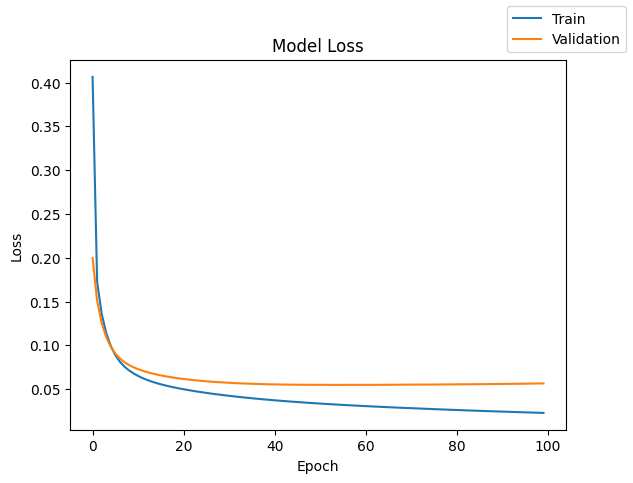

In [95]:
#plot model's loss
plot(history, 'loss')

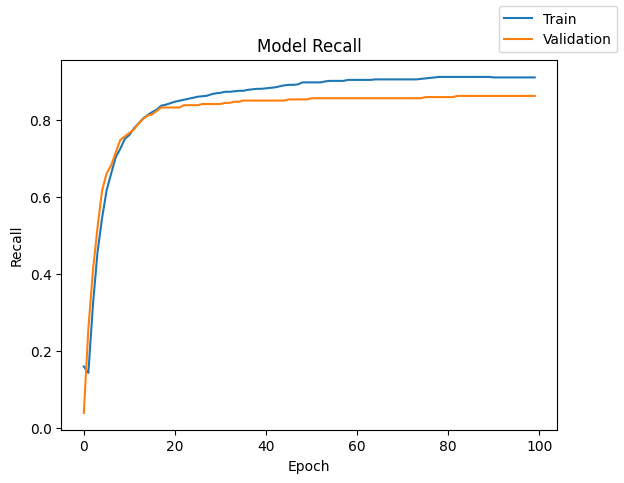

In [96]:
#plot model's recall
plot(history,'recall')

* We see dramatic decreases in training and validation loss until about the 8th epoch, then we start to flatten out around the 20th epoch
* Validation loss remains higher than training loss after about the 7th epoch
* That said, the gap between the two is much narrower, and both loss curves are much smoother than Model 5 with Adam and the default learning rate, and we're not seeing the same level of divergence in the validation loss
* On recall, we see dramatic increases until about the 20th epoch, steady increases until about the 17th epoch, slowing and plateauing
* Validation recall is mostly the same as training until about the 17th epoch, then is consistently lower than training recall

In [97]:
#add model to our results df
results.loc[6] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [1e-4, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "-", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77


## Model 7

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100
* Dropout of 0.2

In [98]:
#setting the dropout rate
dropout_rate = 0.2

In [99]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model7 = Sequential()

#hidden layer
model7.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#dropout layer
model7.add(Dropout(dropout_rate))

#hidden layer
model7.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model7.add(Dense(1, activation = 'sigmoid'))

In [100]:
#looking at model details
model7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [101]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model7.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [102]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model7.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 2s - 15ms/step - loss: 0.2993 - recall: 0.1236 - val_loss: 0.1716 - val_recall: 0.1111
Epoch 2/100
140/140 - 1s - 7ms/step - loss: 0.1630 - recall: 0.2046 - val_loss: 0.1365 - val_recall: 0.3063
Epoch 3/100
140/140 - 1s - 5ms/step - loss: 0.1385 - recall: 0.3295 - val_loss: 0.1195 - val_recall: 0.3964
Epoch 4/100
140/140 - 1s - 4ms/step - loss: 0.1243 - recall: 0.3977 - val_loss: 0.1071 - val_recall: 0.4715
Epoch 5/100
140/140 - 0s - 3ms/step - loss: 0.1100 - recall: 0.4672 - val_loss: 0.0980 - val_recall: 0.5676
Epoch 6/100
140/140 - 1s - 5ms/step - loss: 0.1018 - recall: 0.5380 - val_loss: 0.0913 - val_recall: 0.6396
Epoch 7/100
140/140 - 1s - 4ms/step - loss: 0.0969 - recall: 0.5882 - val_loss: 0.0861 - val_recall: 0.6757
Epoch 8/100
140/140 - 1s - 4ms/step - loss: 0.0905 - recall: 0.6332 - val_loss: 0.0821 - val_recall: 0.7027
Epoch 9/100
140/140 - 1s - 4ms/step - loss: 0.0855 - recall: 0.6589 - val_loss: 0.0793 - val_recall: 0.7327
Epoch 10/100
140/140 - 1s -

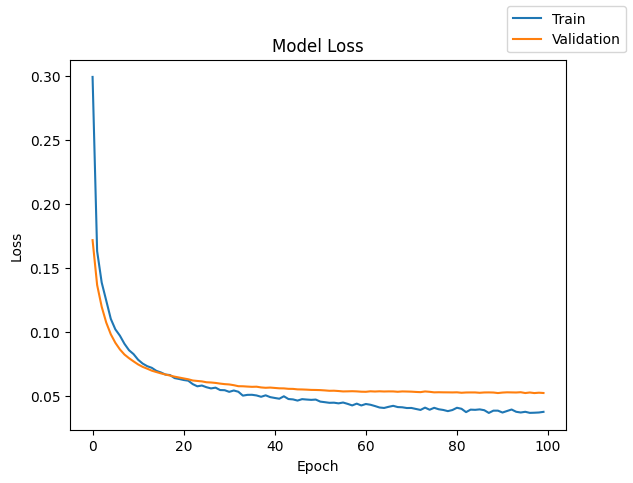

In [103]:
#plot model's loss
plot(history, 'loss')

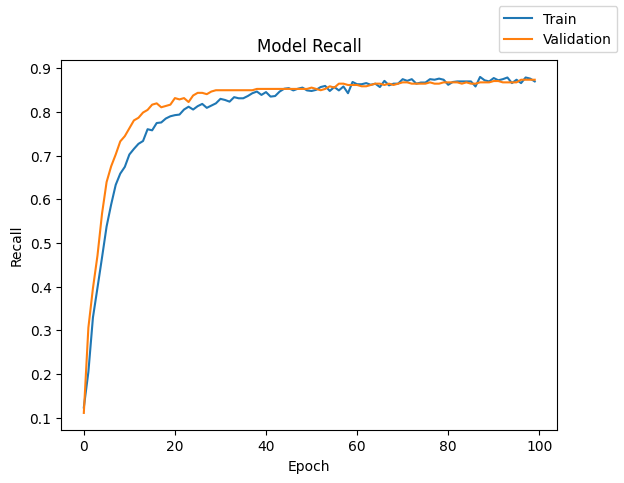

In [104]:
#plot model's recall
plot(history,'recall')

* We see dramatic drops in loss for both training and validation until the  7th epoch, steady decreases until the 20th epoch, then a flattening trend
* Validation loss is mostly the same as training loss until about the 20th epoch, then remains consistently higher
* Training loss oscillates quite a bit, but validation does not
* For recall, both validation and training see dramatic increases until about 17th epoch, then validation remains higher than training until about the 42nd epoch, when both are mostly the same
* Training recall oscillates much more than validation

In [105]:
#add model to our results df
results.loc[7] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  "Dropout (0.2)", #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20


* Model 7 is the favorite so far -- it has the second highest validation recall score, which is higher than the training recall score, and it has the lowest validation loss score

## Model 8

Plan:
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100
* Dropout of 0.2
* Batch normalization

In [106]:
#setting the dropout rate
dropout_rate = 0.2

In [107]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model8 = Sequential()

#hidden layer
model8.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#batch normalization
model8.add(BatchNormalization())

#dropout layer
model8.add(Dropout(dropout_rate))

#hidden layer
model8.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model8.add(Dense(1, activation = 'sigmoid'))

In [108]:
#looking at model details
model8.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 128 (512.00 B)

In [109]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model8.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [110]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model8.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 3s - 18ms/step - loss: 0.3129 - recall: 0.2857 - val_loss: 0.2006 - val_recall: 0.2943
Epoch 2/100
140/140 - 1s - 7ms/step - loss: 0.1763 - recall: 0.3012 - val_loss: 0.1409 - val_recall: 0.3904
Epoch 3/100
140/140 - 1s - 4ms/step - loss: 0.1358 - recall: 0.3848 - val_loss: 0.1139 - val_recall: 0.4895
Epoch 4/100
140/140 - 1s - 4ms/step - loss: 0.1145 - recall: 0.4582 - val_loss: 0.0992 - val_recall: 0.5556
Epoch 5/100
140/140 - 1s - 4ms/step - loss: 0.1007 - recall: 0.5109 - val_loss: 0.0892 - val_recall: 0.6216
Epoch 6/100
140/140 - 1s - 6ms/step - loss: 0.0915 - recall: 0.5779 - val_loss: 0.0825 - val_recall: 0.6607
Epoch 7/100
140/140 - 1s - 6ms/step - loss: 0.0843 - recall: 0.6023 - val_loss: 0.0775 - val_recall: 0.6877
Epoch 8/100
140/140 - 1s - 10ms/step - loss: 0.0791 - recall: 0.6371 - val_loss: 0.0736 - val_recall: 0.7087
Epoch 9/100
140/140 - 1s - 7ms/step - loss: 0.0764 - recall: 0.6628 - val_loss: 0.0704 - val_recall: 0.7327
Epoch 10/100
140/140 - 1s 

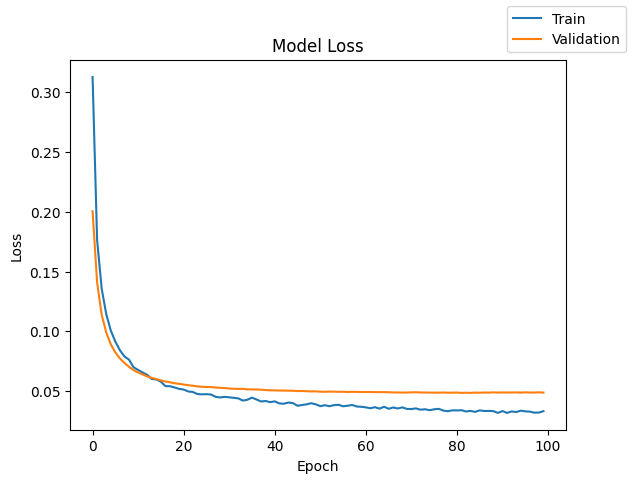

In [111]:
#plot model's loss
plot(history, 'loss')

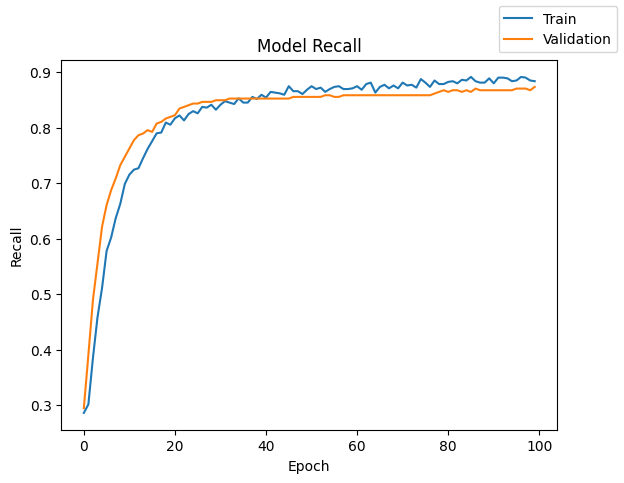

In [112]:
#plot model's recall
plot(history,'recall')

* We see dramatic drops in loss until about the 8th epoch, then we mostly flatten out after the 20th epoch
* Validation loss is lower than training loss until about 18th epoch, then it remains higher -- but the gap is slim
* For recall, we see more oscillation in training than validation
* Both have dramatic increases until the 18th epoch before slowing down and flattening
* Validation recall remains higher until about the 38th epoch, when training recall remains higher

In [113]:
#add model to our results df
results.loc[8] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  ["Batch norm", "Dropout (0.2)"], #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20
8,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2)]",0.033345,0.048828,0.884170,0.873874,70.80


## Model 9

Plan:
* Adjusting class weights for imbalanced class distribution
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100
* Dropout of 0.2
* Batch normalization

In [114]:
#calculate class weights
cw = (y_train.shape[0]) / np.bincount(y_train)

#create a dictionary with class indices and their weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.0587612493382743, 1: 18.01801801801802}

In [115]:
#setting the dropout rate
dropout_rate = 0.2

In [116]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model9 = Sequential()

#hidden layer
model9.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#batch normalization
model9.add(BatchNormalization())

#dropout layer
model9.add(Dropout(dropout_rate))

#hidden layer
model9.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model9.add(Dense(1, activation = 'sigmoid'))

In [117]:
#looking at model details
model9.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 128 (512.00 B)

In [118]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model9.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [119]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model9.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, class_weight = cw_dict, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 4s - 26ms/step - loss: 1.1896 - recall: 0.7439 - val_loss: 0.5574 - val_recall: 0.7988
Epoch 2/100
140/140 - 2s - 12ms/step - loss: 0.8693 - recall: 0.8391 - val_loss: 0.4032 - val_recall: 0.8138
Epoch 3/100
140/140 - 1s - 4ms/step - loss: 0.7422 - recall: 0.8584 - val_loss: 0.3318 - val_recall: 0.8348
Epoch 4/100
140/140 - 1s - 4ms/step - loss: 0.6778 - recall: 0.8649 - val_loss: 0.2931 - val_recall: 0.8529
Epoch 5/100
140/140 - 1s - 4ms/step - loss: 0.6183 - recall: 0.8816 - val_loss: 0.2621 - val_recall: 0.8619
Epoch 6/100
140/140 - 1s - 4ms/step - loss: 0.5824 - recall: 0.8842 - val_loss: 0.2408 - val_recall: 0.8709
Epoch 7/100
140/140 - 1s - 4ms/step - loss: 0.5532 - recall: 0.8932 - val_loss: 0.2252 - val_recall: 0.8649
Epoch 8/100
140/140 - 1s - 4ms/step - loss: 0.5343 - recall: 0.8932 - val_loss: 0.2133 - val_recall: 0.8769
Epoch 9/100
140/140 - 1s - 5ms/step - loss: 0.5061 - recall: 0.9060 - val_loss: 0.2010 - val_recall: 0.8769
Epoch 10/100
140/140 - 1s 

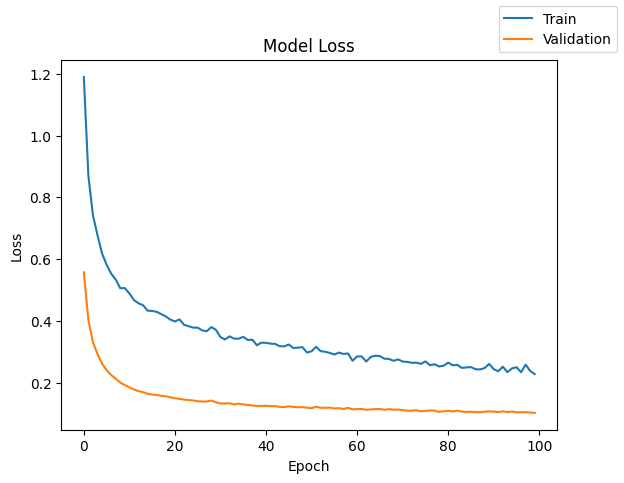

In [120]:
#plot model's loss
plot(history, 'loss')

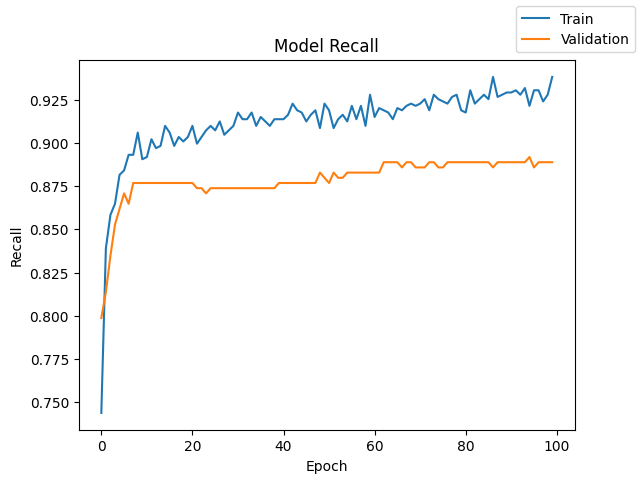

In [121]:
#plot model's recall
plot(history,'recall')

* Training and validation loss fall dramatically until about the 10th epoch, then both slow down and plateau -- though the validation plateau is much flatter
* Validation loss is also lower than training loss
* For recall, both see dramatic increases until about 8 epochs, then training keeps rising while oscillating
* Meantime, validation recall drops slightly before slight increases with plateaus and oscillations
* The gap between training and recall is wider

In [122]:
#add model to our results df
results.loc[9] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  ["Batch norm", "Dropout (0.2)", "Class weights"], #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20
8,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2)]",0.033345,0.048828,0.884170,0.873874,70.80
9,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2), Class weights]",0.228204,0.102644,0.938224,0.888889,71.53


* Model 9 achieved the highest validation recall we've seen thus far, but it's lower than the training recall
* Model 9's validation loss is also on the higher end, though it isn't the highest

## Model 10

Plan:
* Adjusting class weights for imbalanced class distribution
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100
* Dropout of 0.2
* Batch normalization
* He initialization

In [123]:
#calculate class weights
cw = (y_train.shape[0]) / np.bincount(y_train)

#create a dictionary with class indices and their weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.0587612493382743, 1: 18.01801801801802}

In [124]:
#setting the dropout rate
dropout_rate = 0.2

In [125]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model10 = Sequential()

#hidden layer
model10.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],), kernel_initializer = 'he_normal'))

#batch normalization
model10.add(BatchNormalization())

#dropout layer
model10.add(Dropout(dropout_rate))

#hidden layer
model10.add(Dense(128, activation = 'relu', kernel_initializer = 'he_normal'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model10.add(Dense(1, activation = 'sigmoid')) #leaving default Xavier initialization for the output layer since it's sigmoid

In [126]:
#looking at model details
model10.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 128 (512.00 B)

In [127]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model10.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [128]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model10.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, class_weight = cw_dict, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 3s - 19ms/step - loss: 1.1740 - recall: 0.7490 - val_loss: 0.5815 - val_recall: 0.8048
Epoch 2/100
140/140 - 1s - 7ms/step - loss: 0.9178 - recall: 0.8237 - val_loss: 0.4536 - val_recall: 0.8408
Epoch 3/100
140/140 - 1s - 4ms/step - loss: 0.8096 - recall: 0.8378 - val_loss: 0.3854 - val_recall: 0.8408
Epoch 4/100
140/140 - 1s - 5ms/step - loss: 0.7260 - recall: 0.8571 - val_loss: 0.3466 - val_recall: 0.8498
Epoch 5/100
140/140 - 1s - 4ms/step - loss: 0.6946 - recall: 0.8571 - val_loss: 0.3157 - val_recall: 0.8498
Epoch 6/100
140/140 - 1s - 5ms/step - loss: 0.6504 - recall: 0.8674 - val_loss: 0.2941 - val_recall: 0.8619
Epoch 7/100
140/140 - 1s - 4ms/step - loss: 0.6329 - recall: 0.8597 - val_loss: 0.2770 - val_recall: 0.8619
Epoch 8/100
140/140 - 1s - 5ms/step - loss: 0.6073 - recall: 0.8752 - val_loss: 0.2653 - val_recall: 0.8649
Epoch 9/100
140/140 - 1s - 4ms/step - loss: 0.5907 - recall: 0.8790 - val_loss: 0.2542 - val_recall: 0.8679
Epoch 10/100
140/140 - 1s -

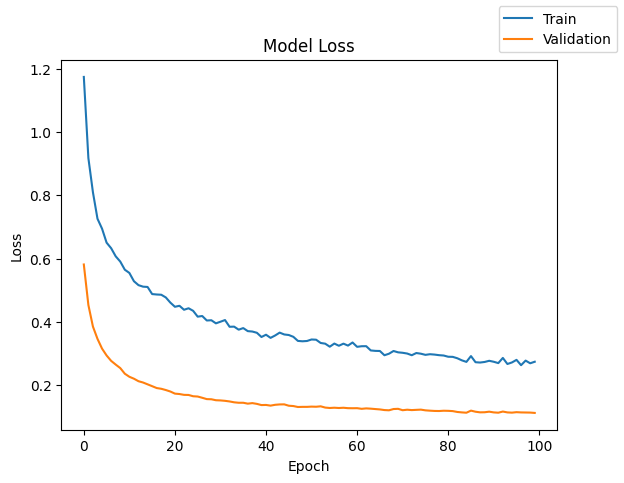

In [129]:
#plot model's loss
plot(history, 'loss')

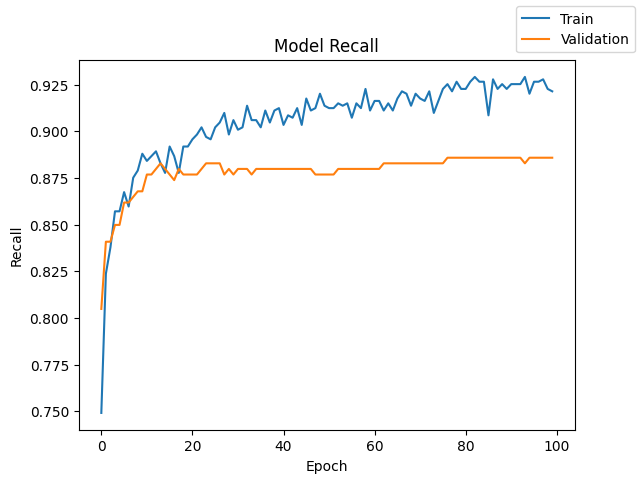

In [130]:
#plot model's recall
plot(history,'recall')

* Validation and training loss fall dramatically until about the 10th epoch before slowing and plateauing
* Training loss oscillates a bit after that
* Validation loss remains consistently lower than training loss the whole time
* For recall, both see dramatic increases until the 10th epoch
* Then, training recall continues rising, with oscillations
* Validation recall continues rising less dramatically before mostly plateauing after the 20th epoch

In [131]:
#add model to our results df
results.loc[10] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["He", "He", "Xav"], #weight initializer
  ["Batch norm", "Dropout (0.2), Class weights"], #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20
8,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2)]",0.033345,0.048828,0.884170,0.873874,70.80
9,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2), Class weights]",0.228204,0.102644,0.938224,0.888889,71.53


## Model 11

Plan:
* Adjusting class weights for imbalanced class distribution
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 100
* L2 regularization

In [132]:
#calculate class weights
cw = (y_train.shape[0]) / np.bincount(y_train)

#create a dictionary with class indices and their weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.0587612493382743, 1: 18.01801801801802}

In [133]:
#initialize model

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model11 = Sequential()

#hidden layer
model11.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],), kernel_regularizer=regularizers.l2(0.001)))

#hidden layer
model11.add(Dense(128, activation = 'relu', kernel_regularizer=regularizers.l2(0.001)))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model11.add(Dense(1, activation = 'sigmoid')) #leaving default Xavier initialization for the output layer since it's sigmoid

In [134]:
#looking at model details
model11.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,073 (43.25 KB)

 Trainable params: 11,073 (43.25 KB)

 Non-trainable params: 0 (0.00 B)

In [135]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model11.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [136]:
#defining batch size and epochs
batch_size = 100
epochs = 100

#fitting model
start = time.time()
history = model11.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, class_weight = cw_dict, verbose = 2)
end=time.time()

Epoch 1/100
140/140 - 2s - 15ms/step - loss: 1.1971 - recall: 0.8571 - val_loss: 0.5610 - val_recall: 0.8559
Epoch 2/100
140/140 - 1s - 7ms/step - loss: 0.8114 - recall: 0.8932 - val_loss: 0.4556 - val_recall: 0.8589
Epoch 3/100
140/140 - 1s - 4ms/step - loss: 0.7157 - recall: 0.9048 - val_loss: 0.4122 - val_recall: 0.8649
Epoch 4/100
140/140 - 1s - 4ms/step - loss: 0.6675 - recall: 0.9099 - val_loss: 0.3877 - val_recall: 0.8649
Epoch 5/100
140/140 - 0s - 3ms/step - loss: 0.6356 - recall: 0.9099 - val_loss: 0.3711 - val_recall: 0.8709
Epoch 6/100
140/140 - 1s - 7ms/step - loss: 0.6109 - recall: 0.9112 - val_loss: 0.3580 - val_recall: 0.8679
Epoch 7/100
140/140 - 1s - 9ms/step - loss: 0.5905 - recall: 0.9086 - val_loss: 0.3476 - val_recall: 0.8619
Epoch 8/100
140/140 - 1s - 5ms/step - loss: 0.5734 - recall: 0.9086 - val_loss: 0.3391 - val_recall: 0.8619
Epoch 9/100
140/140 - 1s - 7ms/step - loss: 0.5587 - recall: 0.9086 - val_loss: 0.3314 - val_recall: 0.8649
Epoch 10/100
140/140 - 0s -

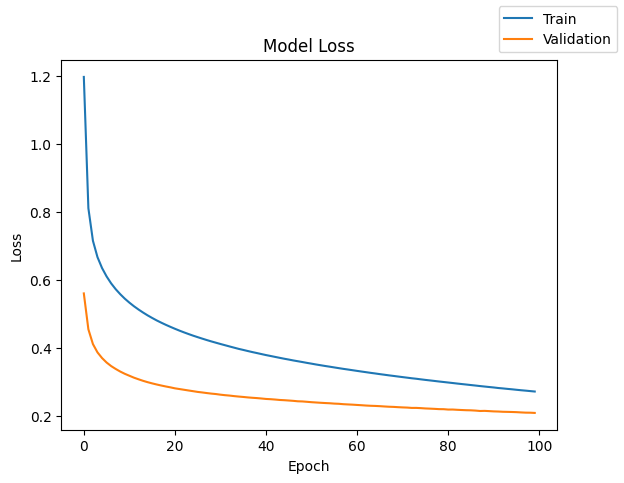

In [137]:
#plot model's loss
plot(history, 'loss')

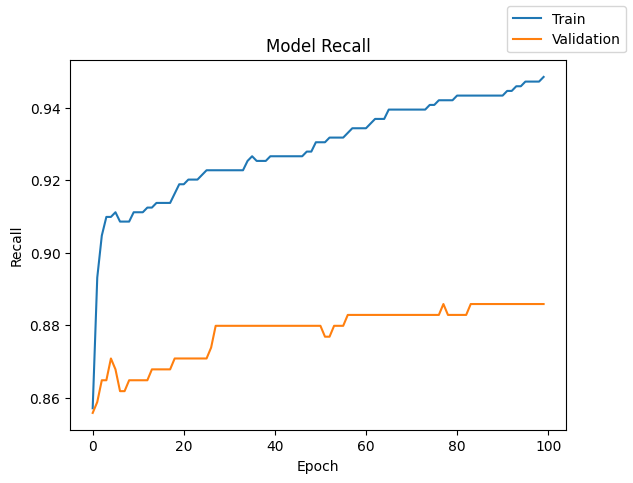

In [138]:
#plot model's recall
plot(history,'recall')

* Validation and training loss fall dramatically until about the 9th epoch, then slow down
* Validation loss is consistently lower than training loss
* For recall, validation increases greatly until around the 7th epoch, falls, then rises gradually before a flattening trend after the 30th epoch
* Meantime, training recall increases dramatically until about the 7th epoch, then continues rising through the end
* There is a wide gap between the two

In [139]:
#add model to our results df
results.loc[11] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  ["L2", "L2", "Class weights"], #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20
8,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2)]",0.033345,0.048828,0.884170,0.873874,70.80
9,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2), Class weights]",0.228204,0.102644,0.938224,0.888889,71.53


# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

Identifying the top performers:
* Models 9, 10, and 11 had the highest validation recall of all the models, with Model 9 at the top
* They also had the highest validation loss scores, though since they included class weights and a penalty for misclassifying the minority classes, a higher validation loss score is to be expected
* Model 7 is the only one that had a higher validation recall than training recall
* Models 9, 10, and 11 had lower validation loss than training loss

Choosing between Models 7, 9, 10, 11:
* Model 9 had the highest validation recall score of all the models, plus had the lowest validation loss score among the models with class weights
* So, we'll move forward with Model 9

## Model 12

Plan:
* Early stopping to find optimal version of the best model
* Adjusting class weights for imbalanced class distribution
* Two hidden layers -- 64, 128
* activation function -- relu, relu
* Adam optimizer
* Reduced learning rate of 1e-4 and increase epochs to 800 for early stopping
* Dropout of 0.2
* Batch normalization

In [140]:
#calculate class weights
cw = (y_train.shape[0]) / np.bincount(y_train)

#create a dictionary with class indices and their weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: 1.0587612493382743, 1: 18.01801801801802}

In [141]:
#setting the dropout rate
dropout_rate = 0.2

In [142]:
#build Model 9 again

#introduce early stopping callback -- so we get the best version of our best model
es= keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=15, verbose=1, mode='min', restore_best_weights= True)

#clear keras session
tf.keras.backend.clear_session()

#initialize neural network
model12 = Sequential()

#hidden layer
model12.add(Dense(64, activation = 'relu', input_shape = (X_train.shape[1],)))

#batch normalization
model12.add(BatchNormalization())

#dropout layer
model12.add(Dropout(dropout_rate))

#hidden layer
model12.add(Dense(128, activation = 'relu'))

#output layer -- one node for binary target variable, and sigmoid for a binary classification problem
model12.add(Dense(1, activation = 'sigmoid'))

In [143]:
#looking at model details
model12.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,201 (43.75 KB)

 Non-trainable params: 128 (512.00 B)

In [144]:
#defining optimizer
lr = 1e-4
optimizer = keras.optimizers.Adam(learning_rate = lr)

#compile model, set optimizer and loss function -- binary crossentropy for binary target variable, with recall as metric
model12.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['recall'])

In [145]:
#defining batch size and epochs
batch_size = 100
epochs = 800 #high count combined with early stopping will help find best version of model

#fitting model
start = time.time()
history = model12.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = batch_size, epochs = epochs, callbacks = [es], verbose = 2)
end=time.time()

Epoch 1/800
140/140 - 3s - 22ms/step - loss: 0.3352 - recall: 0.2407 - val_loss: 0.2133 - val_recall: 0.3574
Epoch 2/800
140/140 - 2s - 16ms/step - loss: 0.1789 - recall: 0.2831 - val_loss: 0.1420 - val_recall: 0.4054
Epoch 3/800
140/140 - 1s - 6ms/step - loss: 0.1352 - recall: 0.3861 - val_loss: 0.1141 - val_recall: 0.4775
Epoch 4/800
140/140 - 1s - 4ms/step - loss: 0.1142 - recall: 0.4582 - val_loss: 0.0992 - val_recall: 0.5646
Epoch 5/800
140/140 - 1s - 4ms/step - loss: 0.1010 - recall: 0.5341 - val_loss: 0.0894 - val_recall: 0.6186
Epoch 6/800
140/140 - 1s - 4ms/step - loss: 0.0946 - recall: 0.5598 - val_loss: 0.0826 - val_recall: 0.6667
Epoch 7/800
140/140 - 1s - 4ms/step - loss: 0.0854 - recall: 0.6088 - val_loss: 0.0778 - val_recall: 0.7057
Epoch 8/800
140/140 - 1s - 4ms/step - loss: 0.0808 - recall: 0.6499 - val_loss: 0.0740 - val_recall: 0.7447
Epoch 9/800
140/140 - 1s - 4ms/step - loss: 0.0761 - recall: 0.6641 - val_loss: 0.0706 - val_recall: 0.7568
Epoch 10/800
140/140 - 1s 

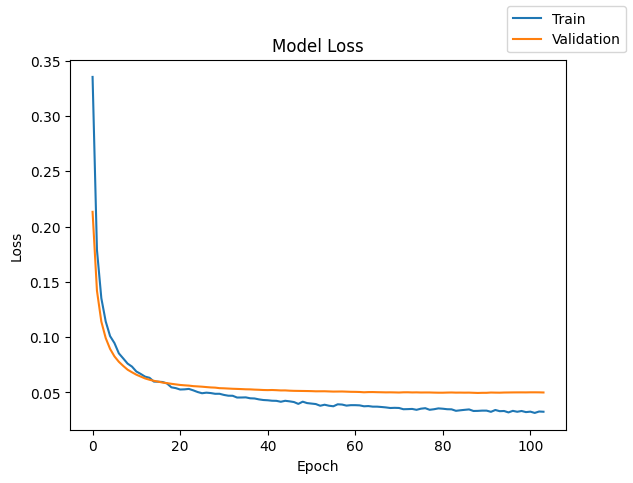

In [146]:
#plot model's loss
plot(history, 'loss')

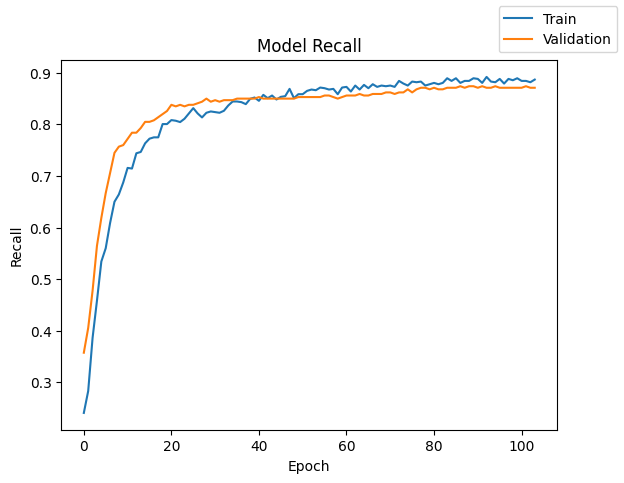

In [147]:
#plot model's recall
plot(history,'recall')

In [148]:
#add model to our results df
results.loc[12] = [
  2, #hidden layers
  [64, 128], #neurons/layer
  ["relu", "relu"], #activation function
  epochs, #epochs
  batch_size, #batch size
  "Adam", #optimizer
  [0.0001, "-"], # learning rate, momentum
  ["Xav", "Xav", "Xav"], #weight initializer
  ["Batch norm", "Dropout (0.2)", "Class weights"], #regularization
  history.history["loss"][-1], #train loss
  history.history["val_loss"][-1], #val loss
  history.history["recall"][-1], #train recall
  history.history["val_recall"][-1], #val recall
  round(end-start,2) #trt
  ]
results

,# hidden layers,# neurons - hidden layer,activation function - hidden layer,# epochs,batch size,optimizer,"learning rate, momentum",weight initializer,regularization,train loss,validation loss,train recall,validation recall,time (secs)
0,1,64,relu,50,100,SGD,"[0.001, -]",-,-,0.051616,0.066721,0.832690,0.804805,34.11
1,2,"[64, 128]","[relu, relu]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.043761,0.060074,0.858430,0.840841,32.27
2,2,"[64, 64]","[relu, tanh]",50,100,SGD,"[0.001, -]","[Xav, Xav, Xav]",-,0.042877,0.054599,0.848134,0.828829,34.36
3,2,"[64, 128]","[relu, relu]",50,100,SGD with mom,"[0.001, 0.9]","[Xav, Xav, Xav]",-,0.019994,0.058086,0.926641,0.873874,32.45
4,2,"[64, 128]","[relu, relu]",100,100,SGD with mom,"[0.0001, 0.9]","[Xav, Xav, Xav]",-,0.069648,0.079240,0.743887,0.738739,69.58
5,2,"[64, 128]","[relu, relu]",50,100,Adam,"[0.001, -]","[Xav, Xav, Xav]",-,0.007486,0.103582,0.963964,0.855856,34.18
6,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",-,0.022967,0.056650,0.909910,0.861862,69.77
7,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]",Dropout (0.2),0.037281,0.052027,0.870013,0.873874,68.20
8,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2)]",0.033345,0.048828,0.884170,0.873874,70.80
9,2,"[64, 128]","[relu, relu]",100,100,Adam,"[0.0001, -]","[Xav, Xav, Xav]","[Batch norm, Dropout (0.2), Class weights]",0.228204,0.102644,0.938224,0.888889,71.53


* Early stop ended training at the 91st epoch and found the best version of Model 12 happened at epoch 89
* Validation recall fell a little bit compared to Model 9, but validation loss fell by almost half

In [149]:
#checking model 12's metrics on the training set
y_train_pred = model12.predict(X_train)
cr_train = classification_report(y_train, y_train_pred > 0.5)
print(cr_train)

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     13223
           1       0.99      0.90      0.94       777

    accuracy                           0.99     14000
   macro avg       0.99      0.95      0.97     14000
weighted avg       0.99      0.99      0.99     14000



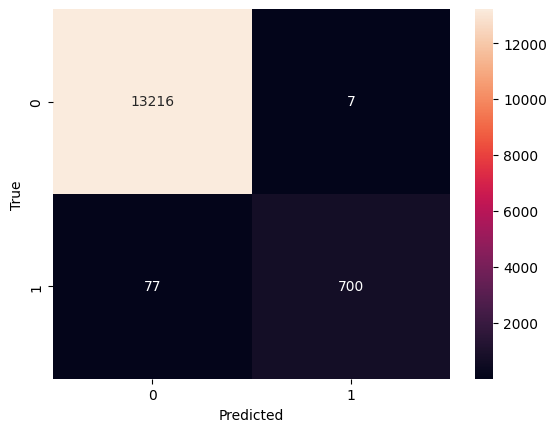

In [150]:
#confusion matrix for training set
cm_train = confusion_matrix(y_train, y_train_pred > 0.5)
sns.heatmap(cm_train, annot = True, fmt = '' )
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

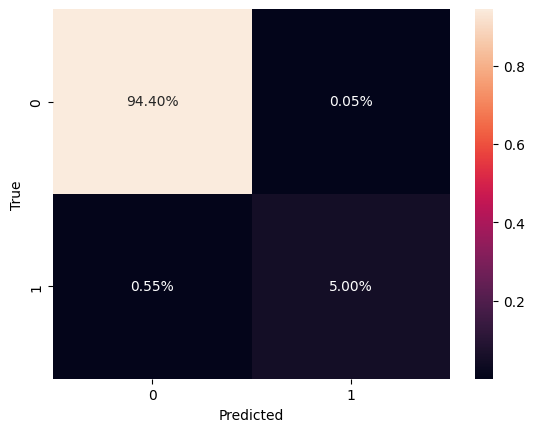

In [151]:
#percentages confusion matrix
sns.heatmap(cm_train/np.sum(cm_train), annot=True, fmt = '.2%')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [152]:
#checking model 12's metrics on the validation set
y_val_pred = model12.predict(X_val)
cr_val = classification_report(y_val, y_val_pred > 0.5)
print(cr_val)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      5667
           1       0.98      0.87      0.93       333

    accuracy                           0.99      6000
   macro avg       0.99      0.94      0.96      6000
weighted avg       0.99      0.99      0.99      6000



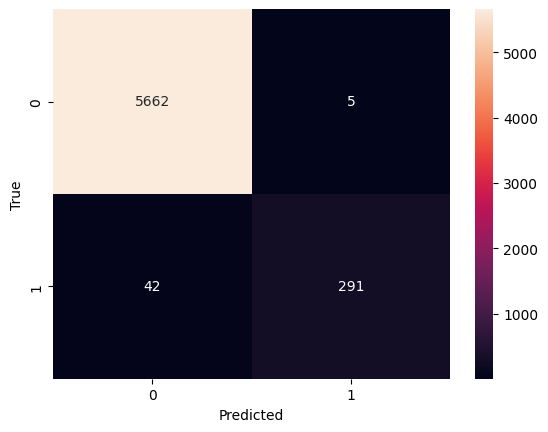

In [153]:
#confusion matrix for validation set
cm_val = confusion_matrix(y_val, y_val_pred > 0.5)
sns.heatmap(cm_val, annot = True, fmt = '' )
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

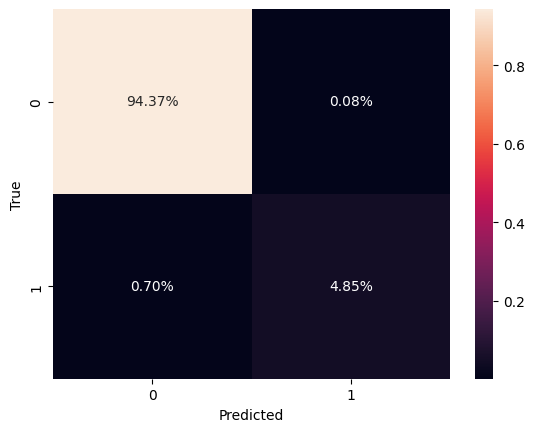

In [154]:
#percentages confusion matrix
sns.heatmap(cm_val/np.sum(cm_val), annot=True, fmt = '.2%')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Now, let's check the performance of the final model on the test set.

In [155]:
score = model12.evaluate(X_test, y_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0523 - recall: 0.8279


In [156]:
#checking model 12's metrics on the test set
y_test_pred = model12.predict(X_test)
cr_test = classification_report(y_test, y_test_pred > 0.5)
print(cr_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4718
           1       0.98      0.86      0.92       282

    accuracy                           0.99      5000
   macro avg       0.99      0.93      0.96      5000
weighted avg       0.99      0.99      0.99      5000



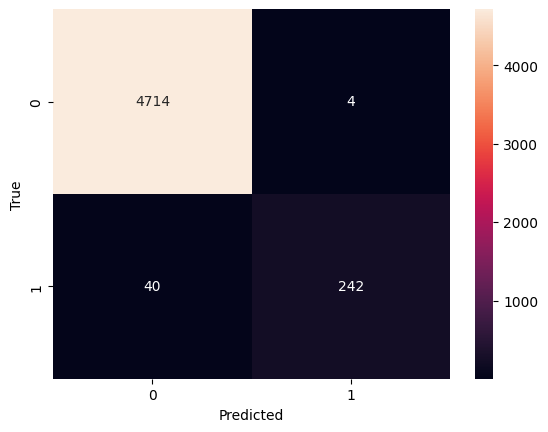

In [157]:
#confusion matrix for test set
cm_test = confusion_matrix(y_test, y_test_pred > 0.5)
sns.heatmap(cm_test, annot=True, fmt = '')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

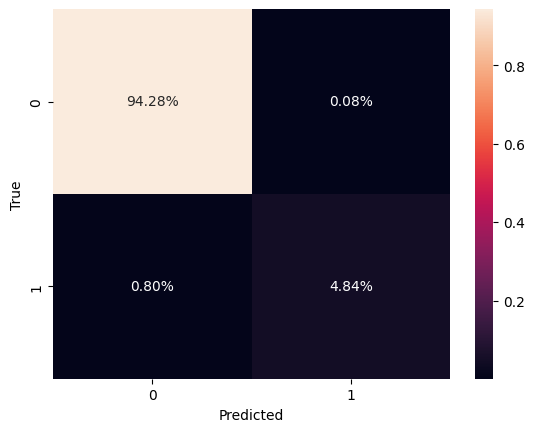

In [158]:
#percentages confusion matrix
sns.heatmap(cm_test/np.sum(cm_test), annot=True, fmt = '.2%')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Actionable Insights and Recommendations**

Write down some insights and business recommendations based on your observations.

* Model 12, our final model, achieved a loss score of 0.0523 and a recall score of 0.8279 on the unseen test set
* The loss is a big improvement from Model 9 (0.1026), which is an early version of Model 12, and is very close to Model 12's loss score on the validation set (0.0500)
* The recall score is a bit lower than Model 12's validation recall score (0.8708)
* The classification report shows Model 12 was basically perfect at identifying generators that would not fail, and 86% successful at identifying generators that would fail
* There is room for improvement in this model, given the difference between the test set recall score and the validation recall score. Further optimizations could be attempted on Model 12 -- including adding more hidden layers, adding different numbers of neurons to those layers, adding and removing Batch Normalization and Dropout layers, testing different Dropout levels, further reducing the learning rate and increasing the number of epochs, and re-itroducing He initialization (which didn't seem to help much in Model 10, but perhaps it would be more effective on Model 12). L1 and L2 regularization could also be introduced; we never tried L1 regularization, so there is opportunity there.
* That said, Model 12 does a great job of minimizing the number of "false negative" generator failure predictions -- only 0.80% of cases the model predicted to not fail, ended up failing (where 0 is "no failure" and 1 is "failure")
* This means the number of cases resulting in costly replacements is very low
* ReneWind should maintain an aggressive policy of inspections, since inspections are cheaper than replacements or repairs. In addition to inspecting any generators Model 12 predicts will fail, the company can do spot inspections on a percentage of the generators Model 12 predicts will not fail -- in an effort to catch some of the false negatives that do make it through -- since doing an extra inspection will ultimately be cheaper than doing a replacement, which is what the false negatives will ultimately result in